<div style="text-align: center;">
    <h2>Rapport du Data</h2>
</div>

### ***Sujet*** : Modélisation de l’attrition des clients (churn) d’une banque.

### ***Objectif*** : Utiliser des techniques (differents algorithmes) de Machine Learning pour prédire si un client va quitter la banque.

Fait par :

- Salwa Boudih 
- Habiba Boukobba
- Ghita sbaaii
- widad ouanas
- Fatima-zzahra Sahih 

# I.Importation des bibliothèques

In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# II. Chargement et Exploration des Données

In [152]:
df=pd.read_csv('Churn_Modelling_raw_data.csv')

In [153]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [154]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

### Description du Colonne :	
- ***RowNumber***	:Numéro de ligne (index de la ligne dans le fichier d'origine, peut être ignoré)

- ***CustomerId*** :	Identifiant unique du client
Surname	Nom de famille du client
- ***CreditScore*** :	Score de crédit (plus c’est élevé, mieux c’est)
- ***Geography*** : Pays de résidence du client (France, Espagne, Allemagne, etc.)
- ***Gender*** :Sexe du client (Male ou Female)
- ***Age***	:Âge du client
- ***Tenure*** :Ancienneté en années avec la banque
- ***Balance*** :Solde du compte du client
- ***NumOfProducts*** :Nombre de produits bancaires utilisés (carte, prêt, etc.)
- ***HasCrCard***	:Le client possède-t-il une carte de crédit ? (1 = Oui, 0 = Non)
- ***IsActiveMember*** :Le client est-il un membre actif ? (1 = Oui, 0 = Non)
- ***EstimatedSalary***	:Salaire estimé du client
- ***Exited***: Cible à prédire : le client a-t-il quitté la banque ? (1 = Oui, 0 = Non)

In [155]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


# III. Pretretement des donnees :

## ***1.Gestion des valeurs manquantes*** s'ils existent :

In [156]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## ***2.Suppression des doublons , if exists*** :

In [157]:
df.duplicated().sum()

np.int64(0)

## ***3.Détection et gestion des valeurs aberrantes***

In [158]:
df.select_dtypes(exclude=['object'])

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,619,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,608,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,502,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,699,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,850,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,771,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,516,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,709,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,772,42,3,75075.31,2,1,0,92888.52,1


In [159]:
from scipy import stats

def detect_outliers(df, column):
    z_scores = stats.zscore(df[column])
    threshold = 3
    outliers = df[np.abs(z_scores) > threshold][column]
    return outliers

def remove_outliers(df, column):
    z_scores = stats.zscore(df[column])
    threshold = 3
    new_df = df[np.abs(z_scores) < threshold]
    return new_df


### --> Détection des valeurs aberrantes : La fonction detect_outliersutilise le Z-score (écart en nombre d'écarts-types par rapport à la moyenne). Si une valeur dépasse un seuil (3), elle est considérée comme une valeur aberrante.

### Suppression des valeurs aberrantes : La fonction remove_outliers filtre les valeurs dont le Z-score est inférieur à 3, supprimant ainsi les valeurs extrêmes.  (Cette fonction de suppression s'applique si la colonne etudiee suit une loi normale , sinon on utilise la methode ***IQR***)

In [160]:
for i in df.select_dtypes(exclude=['object']) :
    print(f"Colonne {i}: {detect_outliers(df, i).count()}")

Colonne RowNumber: 0
Colonne CustomerId: 0
Colonne CreditScore: 8
Colonne Age: 133
Colonne Tenure: 0
Colonne Balance: 0
Colonne NumOfProducts: 60
Colonne HasCrCard: 0
Colonne IsActiveMember: 0
Colonne EstimatedSalary: 0
Colonne Exited: 0


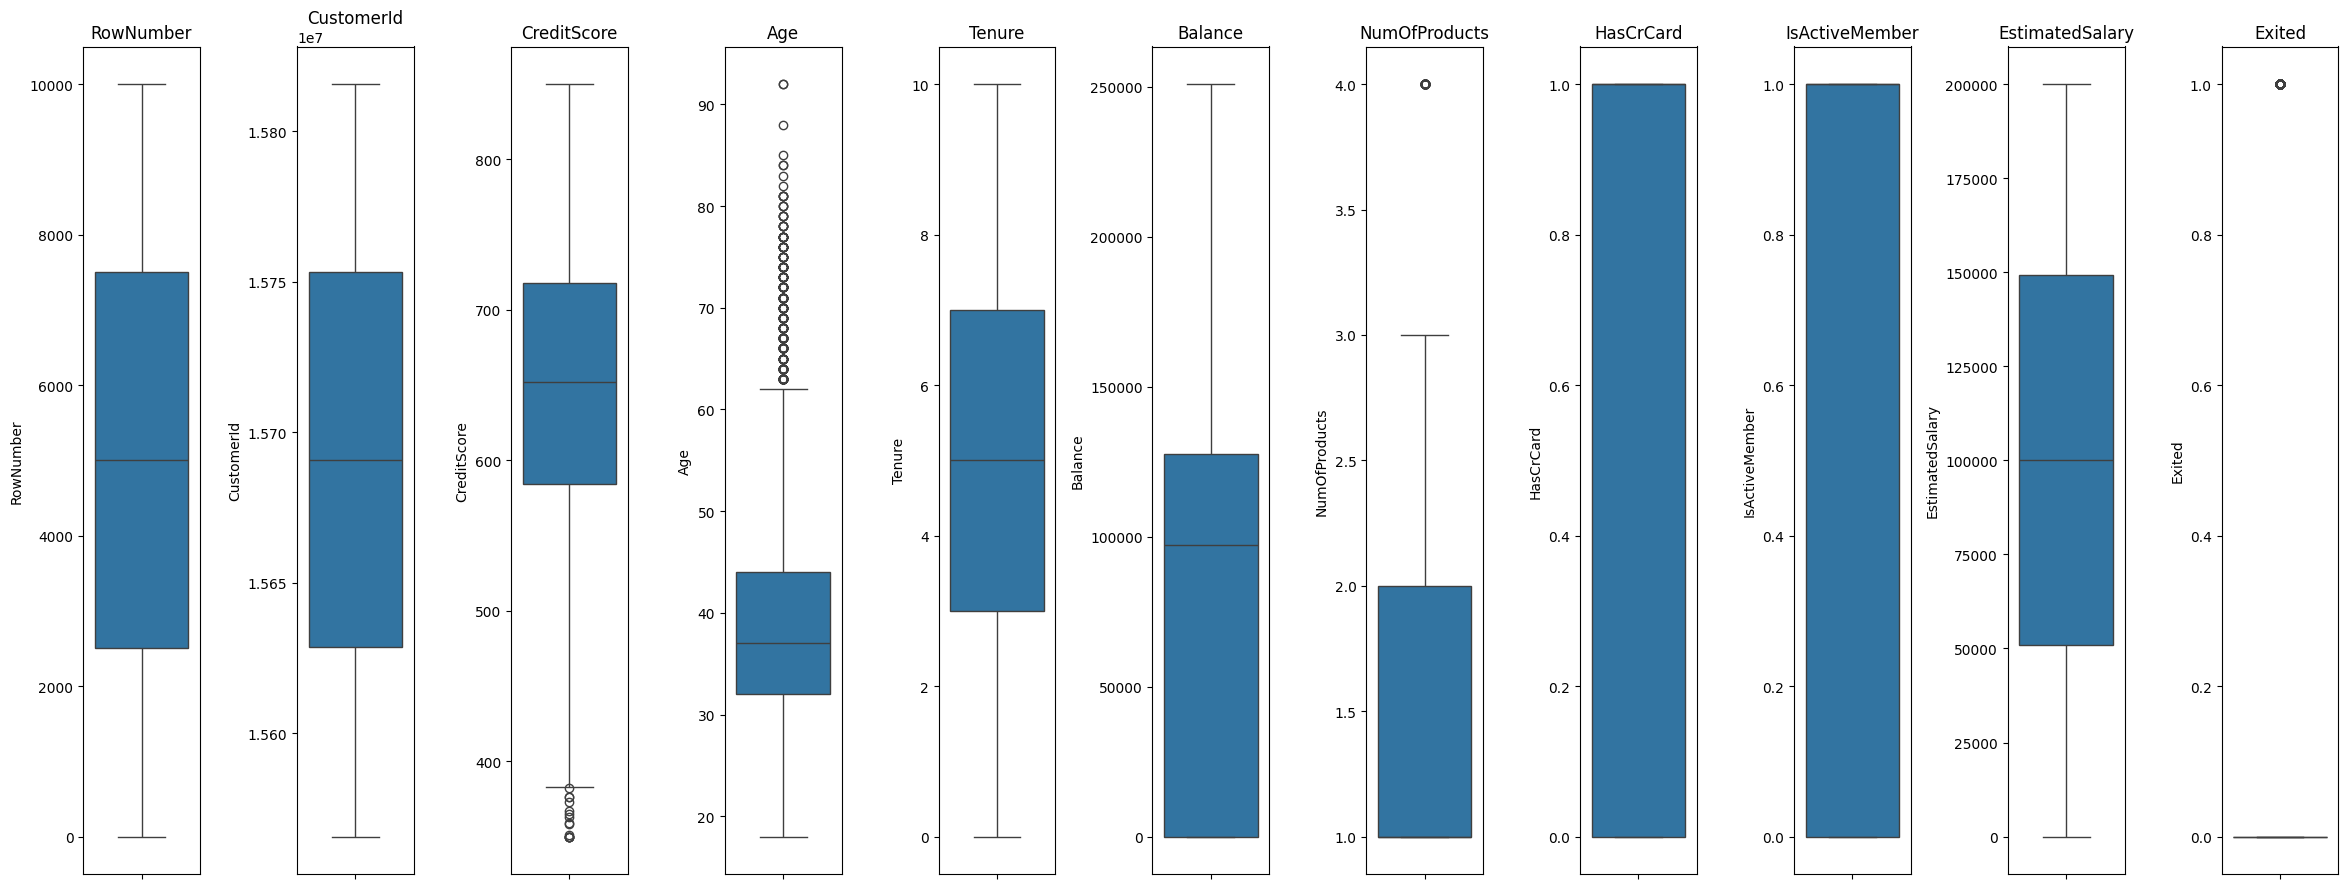

In [161]:
plt.figure(figsize=(30, 9))  # Ajuste la taille du graphique

for i, col in enumerate(df.select_dtypes(include='number').columns, 1,):
    plt.subplot(1, len(df.columns), i)  # Crée des sous-graphiques côte à côte
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()  # Ajuste les espacements
plt.show()

### Pour la colonne ***CreditScore*** :

In [162]:
Q1 = df['CreditScore'].quantile(0.25)  
Q3 = df['CreditScore'].quantile(0.75)  
IQR = Q3 - Q1  
lower_bound = Q1 - 1.5 * IQR  
upper_bound = Q3 + 1.5 * IQR  

In [163]:
df.shape

(10000, 14)

In [164]:
df['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

In [165]:
df['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

In [166]:
df.shape

(10000, 14)

### pour la colonne ***NumOfProducts***

In [167]:
df['NumOfProducts'].describe()

count    10000.000000
mean         1.530200
std          0.581654
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: NumOfProducts, dtype: float64

In [168]:
df['NumOfProducts'].describe()

count    10000.000000
mean         1.530200
std          0.581654
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: NumOfProducts, dtype: float64

In [169]:
for i in df.select_dtypes(exclude=['object']) :
    print(f"Colonne {i}: {detect_outliers(df, i).count()}")

Colonne RowNumber: 0
Colonne CustomerId: 0
Colonne CreditScore: 8
Colonne Age: 133
Colonne Tenure: 0
Colonne Balance: 0
Colonne NumOfProducts: 60
Colonne HasCrCard: 0
Colonne IsActiveMember: 0
Colonne EstimatedSalary: 0
Colonne Exited: 0


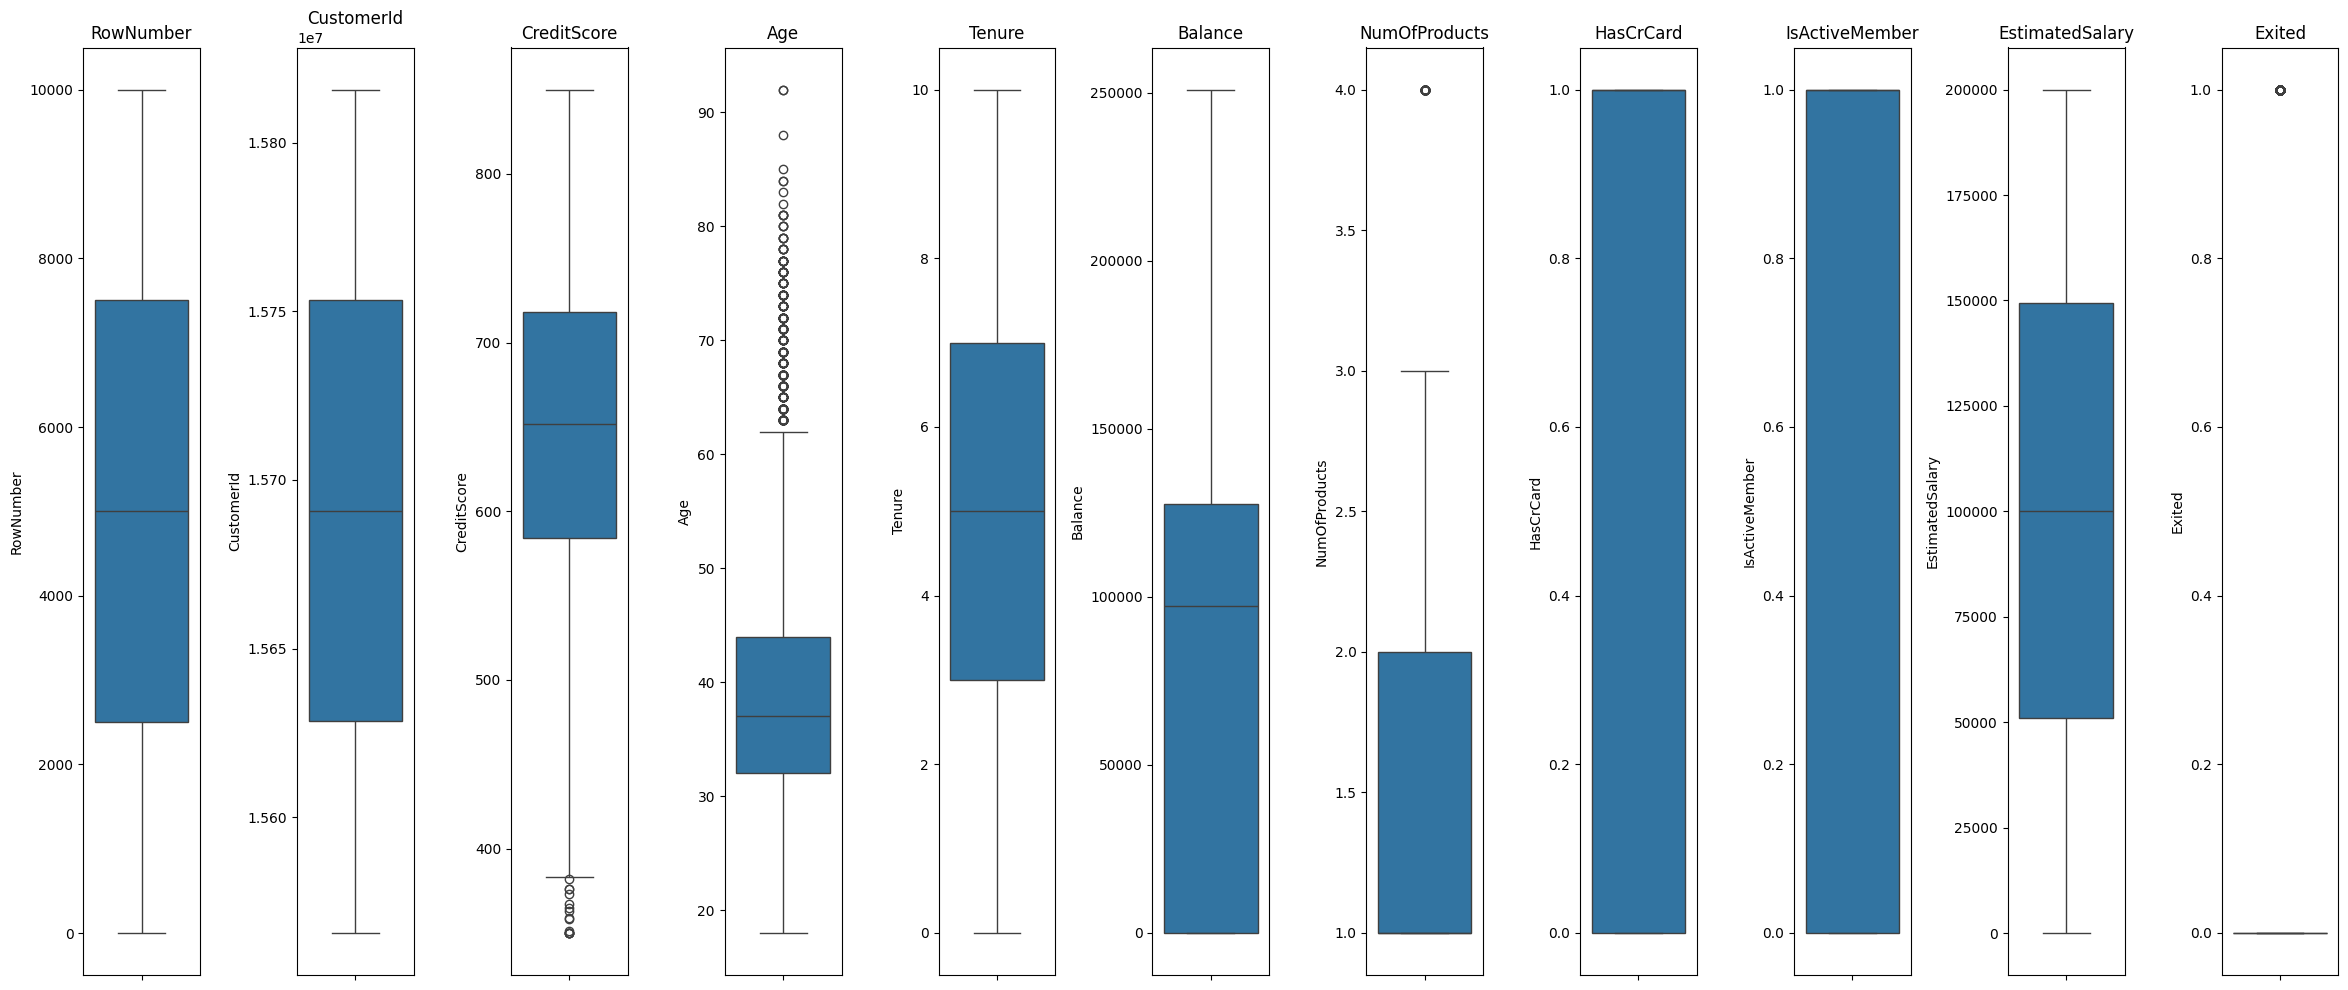

In [170]:
plt.figure(figsize=(30, 10))  # Ajuste la taille du graphique

for i, col in enumerate(df.select_dtypes(include='number').columns, 1,):
    plt.subplot(1, len(df.columns), i)  # Crée des sous-graphiques côte à côte
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()  # Ajuste les espacements
plt.show()

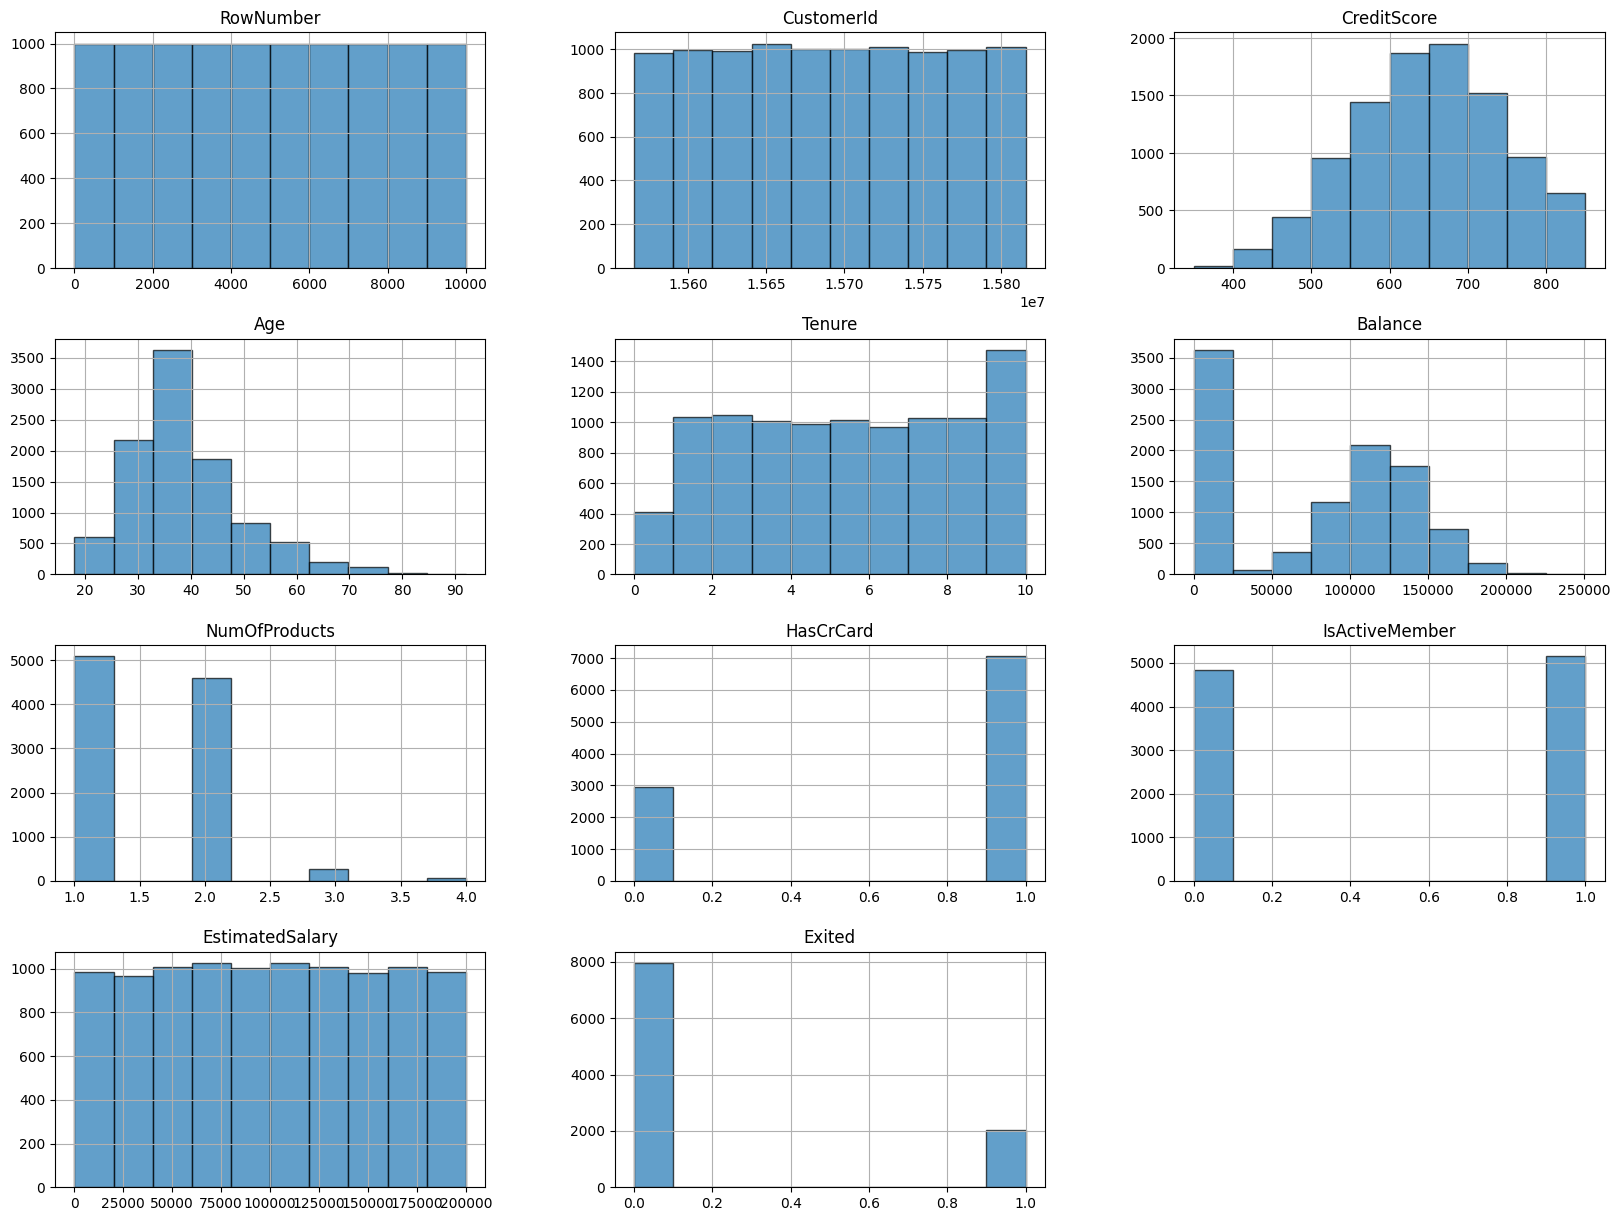

In [171]:
df.hist(edgecolor='black', alpha=0.7 , figsize=(20,15))

plt.show()

## ***5. ENCODING : Nettoyage des chaînes de caractères***

In [172]:
df.select_dtypes(include=['object'])

C:\Users\sohaib bakkali\AppData\Local\Temp\ipykernel_21000\2335824009.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object'])


,Surname,Geography,Gender
0,Hargrave,France,Female
1,Hill,Spain,Female
2,Onio,France,Female
3,Boni,France,Female
4,Mitchell,Spain,Female
...,...,...,...
9995,Obijiaku,France,Male
9996,Johnstone,France,Male
9997,Liu,France,Female
9998,Sabbatini,Germany,Male


### Pour la colonne ***Geography*** :

In [173]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

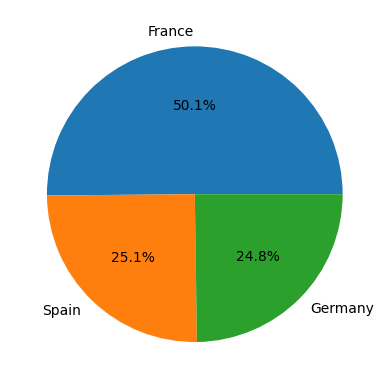

In [174]:
plt.pie(df['Geography'].value_counts(),labels=df['Geography'].unique(),autopct='%1.1f%%')
plt.show()

In [175]:
from sklearn.preprocessing import LabelEncoder
df['Geography']=LabelEncoder().fit_transform(df['Geography'])

In [176]:
df['Geography'].value_counts()

Geography
0    5014
1    2509
2    2477
Name: count, dtype: int64

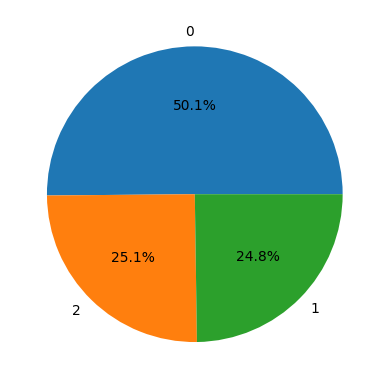

In [177]:
plt.pie(df['Geography'].value_counts(),labels=df['Geography'].unique(),autopct='%1.1f%%')
plt.show()

### Pour la colonne ***Gender*** :

In [178]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

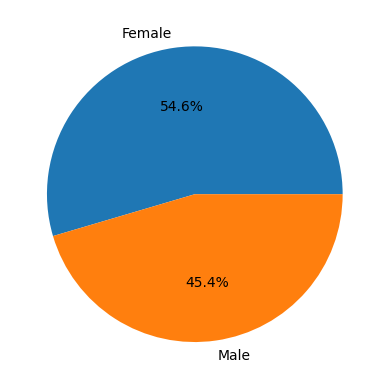

In [179]:
plt.pie(df['Gender'].value_counts(),labels=df['Gender'].unique(),autopct='%1.1f%%')
plt.show()

In [180]:
df= pd.get_dummies(df, columns=['Gender'])

### Pou la colonne ***Exited***

In [181]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

Affiche combien de clients ont quitté (1) ou sont restés (0) dans la banque.

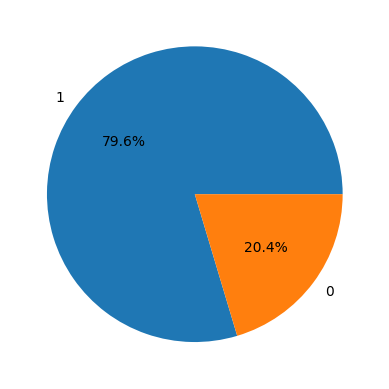

In [182]:
plt.pie(df['Exited'].value_counts(),labels=df['Exited'].unique(),autopct='%1.1f%%')
plt.show()

## HasCrCard

In [183]:
df['HasCrCard'].value_counts()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

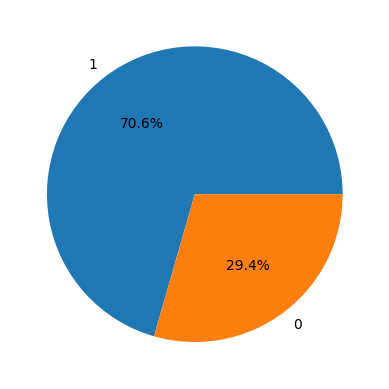

In [184]:
plt.pie(df['HasCrCard'].value_counts(),labels=df['HasCrCard'].unique(),autopct='%1.1f%%')
plt.show()

## IsActiveMember

In [185]:
df['IsActiveMember'].value_counts()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

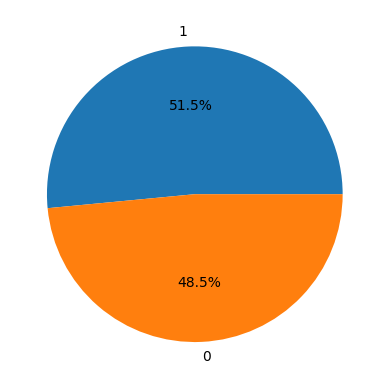

In [186]:
plt.pie(df['IsActiveMember'].value_counts(),labels=df['IsActiveMember'].unique(),autopct='%1.1f%%')
plt.show()

In [187]:
df.shape

(10000, 15)

In [188]:
df.head(2)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Female,Gender_Male
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,True,False
1,2,15647311,Hill,608,2,41,1,83807.86,1,0,1,112542.58,0,True,False


# ***Partie : modele machine learning :***

<div style="text-align: center;">
    <h2>logisticRegression</h2>
</div>

### 1. separation des donnees / Division en train et test

In [189]:
df.drop(columns='Surname' , inplace=True)

In [190]:
# from sklearn.preprocessing import LabelEncoder
# df['Surname']=LabelEncoder().fit_transform(df['Surname'])

In [191]:
x = df.drop(columns=['Exited', 'RowNumber' , 'CustomerId' ])
y = df['Exited']

- Ce code crée une variable x qui contient toutes les colonnes du DataFrame df, sauf celles spécifiées (['Exited', 'RowNumber', 'CustomerId']). Ces colonnes sont supprimées car elles ne sont pas nécessaires pour l'entraînement du modèle. Dans ce cas :
   - Exited : C'est la variable cible (c'est-à-dire ce que nous cherchons à prédire).
   - RowNumber et CustomerId : Ce sont des identifiants qui ne sont généralement pas utiles pour prédire une variable cible.
   
- La variable y contient la colonne Exited, qui représente la variable cible, c'est-à-dire si un client a quitté ou non (généralement une variable binaire).

In [192]:
xl_train, xl_test, yl_train, yl_test = train_test_split(x, y, test_size=0.2, random_state=42)

Cette fonction divise les données en deux ensembles : un ensemble d'entraînement et un ensemble de test.

80% pour l'entraînement (X_train, y_train)

20% pour le test (X_test, y_test)

random_state=42 : pour rendre le tirage reproductible 

### 2. Normalisation 

In [193]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xl_train= scaler.fit_transform(xl_train)
xl_test= scaler.fit_transform(xl_test)

#### Normalisation : Transformation des données pour qu'elles aient une échelle comparable, ce qui est souvent nécessaire pour les modèles de machine learning. 


### 3. Modélisation et entraînement d’un modèle de classification :

 on utilise le modèle de régression logistique pour entraîner un modèle de classification
 - max_iter=1000 définit le nombre maximum d'itérations pour la convergence de l'algorithme d'optimisation. Si l'algorithme ne converge pas avant 1000 itérations, une erreur sera levée.

In [194]:
model = LogisticRegression(max_iter=1000)
model.fit(xl_train, yl_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [195]:
y_predL = model.predict(xl_test)

### 4. Prédiction sur l'ensemble de test / visualisation :

Accuracy: 0.82


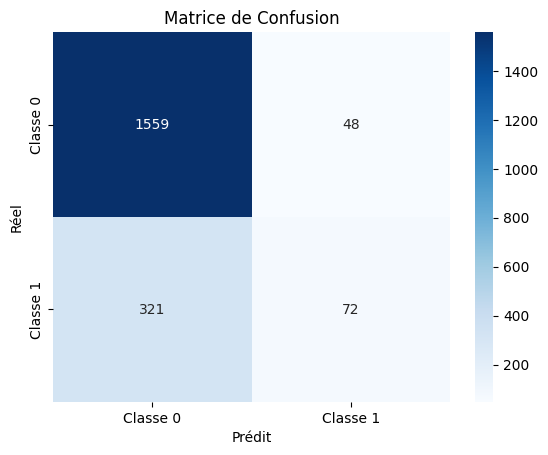

In [196]:
accuracy = accuracy_score(yl_test, y_predL)
print(f"Accuracy: {accuracy:.2f}")

# Matrice de confusion
conf_matrix = confusion_matrix(yl_test, y_predL)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

- La précision du modèle sera affichée sous forme de pourcentage,  Accuracy: 0.82.
- Une matrice de confusion sera affichée à l'écran, permettant de visualiser la performance du modèle en termes de vrais positifs, vrais négatifs, faux positifs et faux négatifs.

In [197]:
accuracyLogistic = accuracy_score(yl_test, y_predL)
print(f"Précision du modèle : {accuracyLogistic:.2f}")
print("\nRapport de classification :\n", classification_report(yl_test, y_predL))

Précision du modèle : 0.82

Rapport de classification :
               precision    recall  f1-score   support

           0       0.83      0.97      0.89      1607
           1       0.60      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.82      0.77      2000



- accuracy_score(yl_test, y_predl) : Cette ligne calcule la précision (accuracy) du modèle, c’est-à-dire le pourcentage de prédictions correctes sur l’ensemble de test.
- classification_report(yl_test, y_predl) : Cette fonction génère un rapport détaillé sur la performance du modèle, incluant les métriques suivantes :
  - precision : La précision pour chaque classe. C'est le nombre de vrais positifs (TP) divisé par la somme des vrais positifs et des faux positifs (FP).
  - recall : Le rappel pour chaque classe. C'est le nombre de vrais positifs (TP) divisé par la somme des vrais positifs et des faux négatifs (FN).
  - f1-score : La moyenne harmonique de la précision et du rappel.

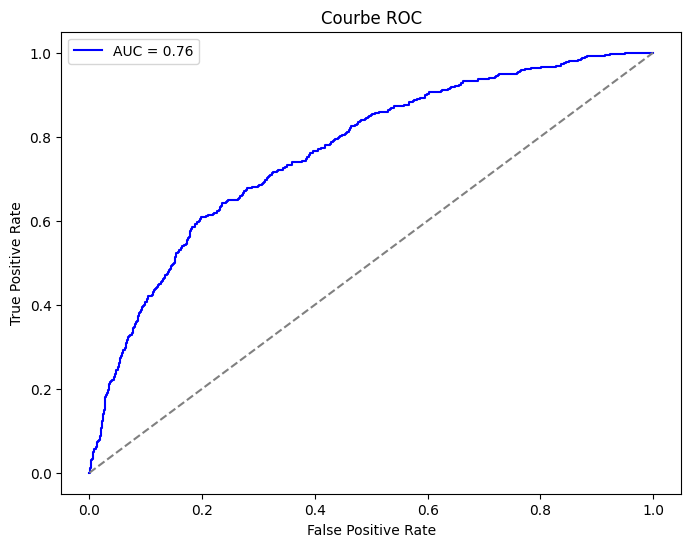

In [198]:
# Calcul de la courbe ROC
y_scoresLog = model.predict_proba(xl_test)[:, 1]
fprlog, tprlog, _ = roc_curve(yl_test, y_scoresLog)
roc_aucLOG = auc(fprlog, tprlog)

plt.figure(figsize=(8, 6))
plt.plot(fprlog, tprlog, color='blue', label=f'AUC = {roc_aucLOG:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()


- Calcul de la courbe ROC pour évaluer le compromis entre le taux de faux positifs et le taux de vrais positifs.
- Calcul de l’AUC pour mesurer la performance globale du modèle.

### 5. Validation des donnes :

In [199]:
from sklearn.model_selection import cross_val_score, KFold

model = model
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x, y, cv=kf)
print(f"Scores de validation croisée : {scores}")
print(f"Score moyen : {scores.mean():.2f}")

c:\Users\sohaib bakkali\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\sohaib bakkali\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown

Scores de validation croisée : [0.815  0.8045 0.8015 0.8145 0.8145]
Score moyen : 0.81


c:\Users\sohaib bakkali\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Le code utilise la validation croisée pour évaluer la performance d'un modèle de machine learning. Cependant, il semble y avoir un avertissement concernant la convergence du modèle, ce qui pourrait nécessiter un ajustement des paramètres ou une normalisation des données.

<div style="text-align: center;">
    <h2>K-Nearest Neighbors</h2>
</div>

### 1. separation des donnees / Division en train et test

In [200]:
xk_train , xk_test , yk_train , yk_test = train_test_split(x, y , test_size=0.20 , random_state=42) 

### 2. Normalisation 

In [201]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xk_train= scaler.fit_transform(xk_train)
xk_test= scaler.fit_transform(xk_test)

#### Normalisation : Transformation des données pour qu'elles aient une échelle comparable, ce qui est souvent nécessaire pour les modèles de machine learning. 


### 3. Modélisation et entraînement du modèle  :

In [202]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(xk_train,yk_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


- Le modèle utilisé ici est le KNeighborsClassifier de la bibliothèque sklearn.
   - Le nombre de voisins (n_neighbors=5) est spécifié pour l'algorithme K-Nearest Neighbors (KNN).
   - La fonction fit est utilisée pour entraîner le modèle en utilisant les données d'entraînement xk_train et yk_train.

In [203]:
y_pred_knn = knn.predict(xk_test)

### 4. Prédiction sur l'ensemble de test / visualisation :

In [204]:
accuracyKnn = accuracy_score(yk_test, y_pred_knn)
print(f"Précision du modèle : {accuracyKnn:.2f}")
print("\nRapport de classification :\n", classification_report(yk_test, y_pred_knn))

Précision du modèle : 0.83

Rapport de classification :
               precision    recall  f1-score   support

           0       0.86      0.94      0.90      1607
           1       0.61      0.37      0.46       393

    accuracy                           0.83      2000
   macro avg       0.73      0.66      0.68      2000
weighted avg       0.81      0.83      0.81      2000



Accuracy: 0.83


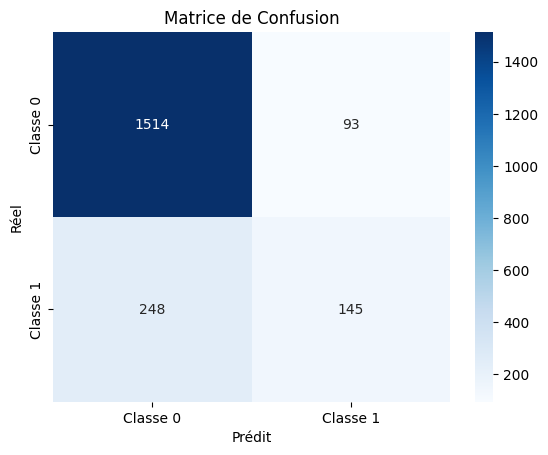

In [205]:
print(f"Accuracy: {accuracyKnn:.2f}")

# Matrice de confusion
conf_matrix = confusion_matrix(yk_test, y_pred_knn)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1' ], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

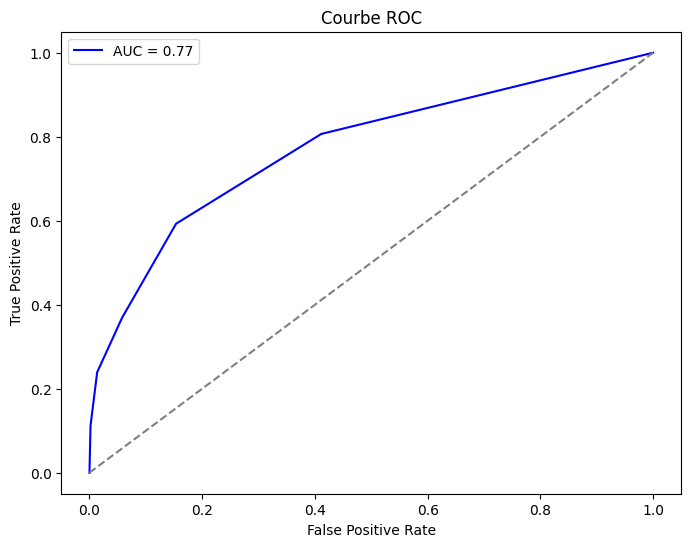

In [206]:
# Calcul de la courbe ROC
y_scores_KNN = knn.predict_proba(xk_test)[:, 1]
fprknn, tprknn, _ = roc_curve(yk_test, y_scores_KNN)
roc_aucKNN = auc(fprknn, tprknn)

# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fprknn, tprknn, color='blue', label=f'AUC = {roc_aucKNN:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

#### Résultat de la courbe ROC : 

La courbe ROC affiche la performance du modèle de manière graphique. L'aire sous la courbe (AUC) est calculée et affichée. Dans ce cas, l'AUC est de 0.77, ce qui indique une performance modérée du modèle (une AUC proche de 1 signifie un excellent modèle).

#### Conclusion :
Cette visualisation permet d'évaluer la performance de votre modèle de classification KNN en termes de compromis entre le taux de faux positifs et le taux de vrais positifs.

### 5. Validation des donnes :

In [207]:
from sklearn.model_selection import cross_val_score, KFold

model = knn
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x, y, cv=kf)
print(f"Scores de validation croisée : {scores}")
print(f"Score moyen : {scores.mean():.2f}")

Scores de validation croisée : [0.764  0.7575 0.7595 0.7675 0.7675]
Score moyen : 0.76


#### Le code utilise la validation croisée pour évaluer la performance d'un modèle de machine learning. Cependant, il semble y avoir un avertissement concernant la convergence du modèle, ce qui pourrait nécessiter un ajustement des paramètres ou une normalisation des données.

<div style="text-align: center;">
    <h2>Decision Tree</h2>
</div>

### 1. separation des donnees / Division en train et test

In [208]:
xd_train, xd_test, yd_train, yd_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Train size: {xd_train.shape}, Test size: {xd_test.shape}")

Train size: (8000, 11), Test size: (2000, 11)


### 2. Normalisation 

In [209]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xd_train= scaler.fit_transform(xd_train)
xd_test= scaler.fit_transform(xd_test)

#### Normalisation : Transformation des données pour qu'elles aient une échelle comparable, ce qui est souvent nécessaire pour les modèles de machine learning. 


### 3. Modélisation et entraînement d’un modèle de classification :

In [210]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
dt.fit(xd_train, yd_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

####  ce code construit et entraîne un arbre de décision avec une profondeur limitée et un critère de Gini pour classifier les données d'entraînement.


1. Critère de Gini : Le critère "gini" est utilisé pour mesurer l'impureté des nœuds dans l'arbre de décision. Moins l'impureté est élevée, meilleur est le modèle.
   
2. max_depth=3 : L'arbre de décision aura une profondeur maximale de 3 niveaux, ce qui limite sa complexité et permet d'éviter le surapprentissage.

3. random_state=42 : Permet de rendre les résultats reproductibles en fixant une valeur pour l'initialisation aléatoire.

4. dt.fit(xd_train, yd_train) : Entraîne le modèle sur les données d'entraînement xd_train et les étiquettes correspondantes yd_train.

In [211]:
y_pred_dt = dt.predict(xd_test)

### 4. Prédiction sur l'ensemble de test / visualisation :

In [212]:
# Évaluation du modèle
accuracy_dt = accuracy_score(yd_test, y_pred_dt)
print(f"Précision du modèle : {accuracy_dt:.2f}")

Précision du modèle : 0.85


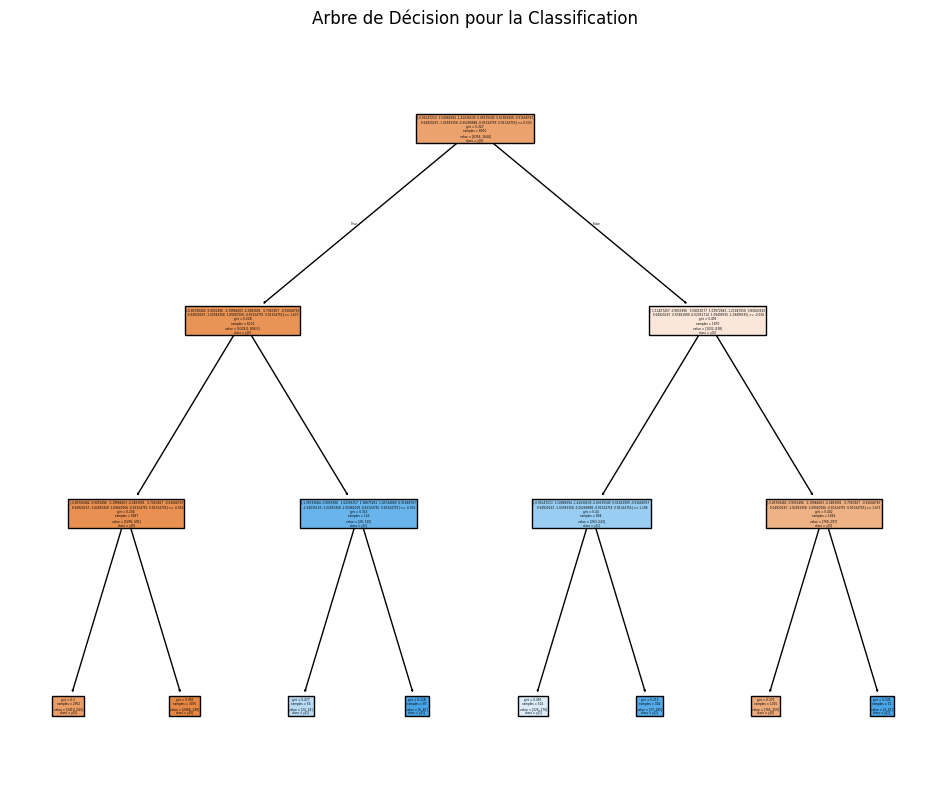

In [213]:
# Visualisation de l’arbre de décision
from sklearn import tree
from sklearn.tree import  plot_tree
plt.figure(figsize=(12, 10))
plot_tree(dt, filled=True, feature_names=xd_train, class_names=True)
plt.title("Arbre de Décision pour la Classification")
plt.show()

<Axes: >

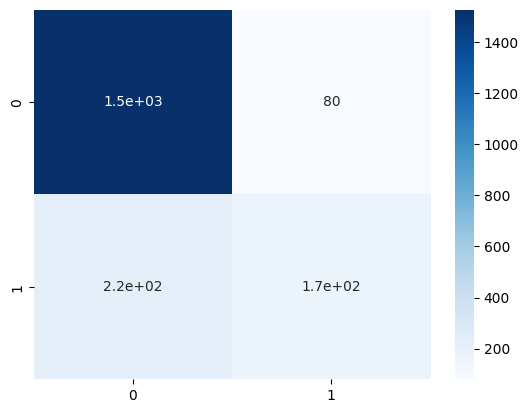

In [214]:
import seaborn as sns

sns.heatmap(confusion_matrix(yd_test, y_pred_dt), annot=True, cmap='Blues')

In [215]:
print(f"Précision du modèle : {accuracy_dt:.2f}")
print("\nRapport de classification :\n", classification_report(yd_test, y_pred_dt))

Précision du modèle : 0.85

Rapport de classification :
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      1607
           1       0.68      0.43      0.53       393

    accuracy                           0.85      2000
   macro avg       0.78      0.69      0.72      2000
weighted avg       0.83      0.85      0.83      2000



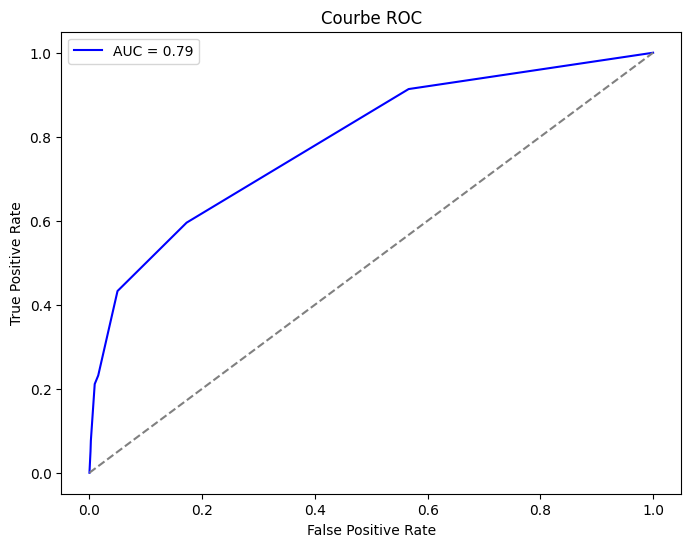

In [216]:
# Calcul de la courbe ROC
y_scores_dt = dt.predict_proba(xd_test)[:, 1]
fprdt, tprdt, _ = roc_curve(yd_test, y_scores_dt)
roc_aucDT = auc(fprdt, tprdt)

# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fprdt, tprdt, color='blue', label=f'AUC = {roc_aucDT:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

### 5. Validation des donnes :

In [217]:
from sklearn.model_selection import cross_val_score, KFold

model = dt
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x, y, cv=kf)
print(f"Scores de validation croisée : {scores}")
print(f"Score moyen : {scores.mean():.2f}")

Scores de validation croisée : [0.8485 0.8365 0.8315 0.8465 0.84  ]
Score moyen : 0.84


#### Le code utilise la validation croisée pour évaluer la performance d'un modèle de machine learning. Cependant, il semble y avoir un avertissement concernant la convergence du modèle, ce qui pourrait nécessiter un ajustement des paramètres ou une normalisation des données.

<div style="text-align: center;">
    <h2>Random Forest</h2>
</div>

### 1. separation des donnees / Division en train et test

In [218]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(x, y, test_size=0.2, random_state=42)

### 2. Normalisation 

In [219]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xr_train= scaler.fit_transform(Xr_train)
Xr_test= scaler.fit_transform(Xr_test)

#### Normalisation : Transformation des données pour qu'elles aient une échelle comparable, ce qui est souvent nécessaire pour les modèles de machine learning. 


### 3. Modélisation et entraînement d’un modèle de classification :

In [220]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(Xr_train, yr_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

#### ce code entraîne un modèle de forêt aléatoire avec 100 arbres pour classer les données d'entraînement et fournit une méthode robuste et précise pour effectuer des prédictions.


1. n_estimators=100 : Le modèle utilise 100 arbres de décision dans la forêt, ce qui permet d'améliorer la précision du modèle en combinant plusieurs prédictions d'arbres différents.

2. random_state=42 : Fixe la valeur de l'état aléatoire pour assurer que les résultats sont reproductibles à chaque exécution du code.

3. rf.fit(Xr_train, yr_train) : Entraîne le modèle sur les données d'entraînement Xr_train (caractéristiques) et yr_train (étiquettes).

In [221]:
Xr_test

array([[-0.51250172,  0.32653736, -0.67729931, ..., -0.99096946,
        -0.90911166,  0.90911166],
       [-0.2360466 , -0.88735616,  0.38429835, ...,  0.8293793 ,
        -0.90911166,  0.90911166],
       [-0.46130633,  1.54043088,  0.48080723, ..., -0.69904548,
         1.09997489, -1.09997489],
       ...,
       [ 0.85953481, -0.88735616,  0.77033387, ..., -1.13742992,
         1.09997489, -1.09997489],
       [ 0.47044982, -0.88735616, -0.96682594, ..., -0.38237688,
        -0.90911166,  0.90911166],
       [-0.18485121,  0.32653736, -0.00173716, ...,  0.15573964,
        -0.90911166,  0.90911166]], shape=(2000, 11))

In [222]:
y_pred_rd = rf.predict(Xr_test)

### 4. Prédiction sur l'ensemble de test / visualisation :

In [223]:
accuracy_rd = accuracy_score(yr_test, y_pred_rd)
print(f"Précision du modèle Random Forest: {accuracy_rd:.2f}")


Précision du modèle Random Forest: 0.87


In [224]:
print(f"Précision du modèle : {accuracy_rd:.2f}")
print("\nRapport de classification :\n", classification_report(yr_test, y_pred_rd))

Précision du modèle : 0.87

Rapport de classification :
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [225]:
# Matrice de confusion
conf_matrix = confusion_matrix(yr_test, y_pred_rd)
print("\nMatrice de confusion :\n", conf_matrix)


Matrice de confusion :
 [[1553   54]
 [ 214  179]]


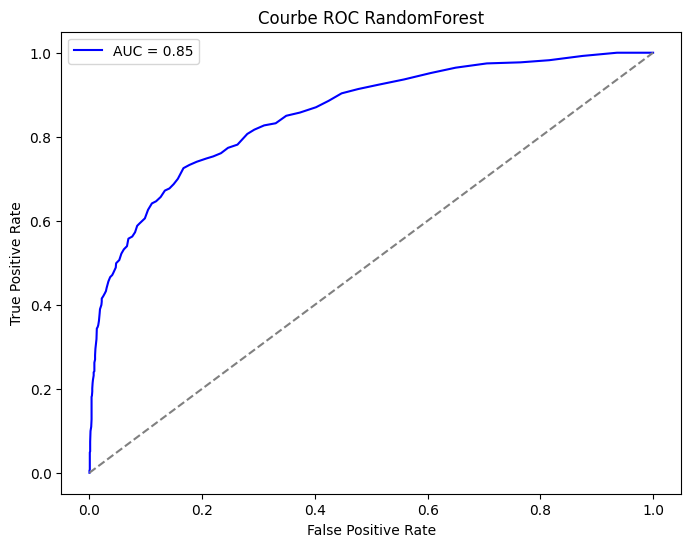

In [226]:
# Calcul de la courbe ROC
y_scoresR = rf.predict_proba(Xr_test)[:, 1]
fprR, tprR, _ = roc_curve(yr_test, y_scoresR)
roc_aucR = auc(fprR, tprR)

plt.figure(figsize=(8, 6))
plt.plot(fprR, tprR, color='blue', label=f'AUC = {roc_aucR:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC RandomForest')
plt.legend()
plt.show()

### 5. Validation des donnes :

In [227]:
from sklearn.model_selection import cross_val_score, KFold

model = rf
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x, y, cv=kf)
print(f"Scores de validation croisée : {scores}")
print(f"Score moyen : {scores.mean():.2f}")

Scores de validation croisée : [0.863  0.857  0.857  0.8665 0.85  ]
Score moyen : 0.86


#### Le code utilise la validation croisée pour évaluer la performance d'un modèle de machine learning. Cependant, il semble y avoir un avertissement concernant la convergence du modèle, ce qui pourrait nécessiter un ajustement des paramètres ou une normalisation des données.

<div style="text-align: center;">
    <h2>SVM: Support Vector Machine</h2>
</div>

### 1. separation des donnees / Division en train et test

In [228]:
X_trainS, X_testS, y_trainS, y_testS = train_test_split(x, y, test_size=0.2, random_state=42)

### 2. Normalisation 

In [229]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_trainS= scaler.fit_transform(X_trainS)
X_testS= scaler.fit_transform(X_testS)

#### Normalisation : Transformation des données pour qu'elles aient une échelle comparable, ce qui est souvent nécessaire pour les modèles de machine learning. 

### 3. Modélisation et entraînement d’un modèle de classification :

In [230]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_trainS, y_trainS)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### le code utilise un modèle SVM pour apprendre les relations entre les données d'entrée et les classes de sortie, afin de pouvoir faire des prédictions sur de nouvelles données.


1. SVC() : Cette fonction instancie un modèle de machine à vecteurs de support (SVM), qui est un algorithme de classification supervisée. Par défaut, il utilise un noyau RBF (Radial Basis Function).

2. svm.fit(X_trainS, y_trainS) : Cette ligne entraîne le modèle SVM avec les données d'entraînement X_trainS (caractéristiques) et y_trainS (étiquettes).


### 4. Prédiction sur l'ensemble de test / visualisation :

In [231]:
y_predS = svm.predict(X_testS)

accuracyS = accuracy_score(y_testS, y_predS)
print(f"Accuracy: {accuracyS:.2f}")

Accuracy: 0.86


Accuracy: 0.86


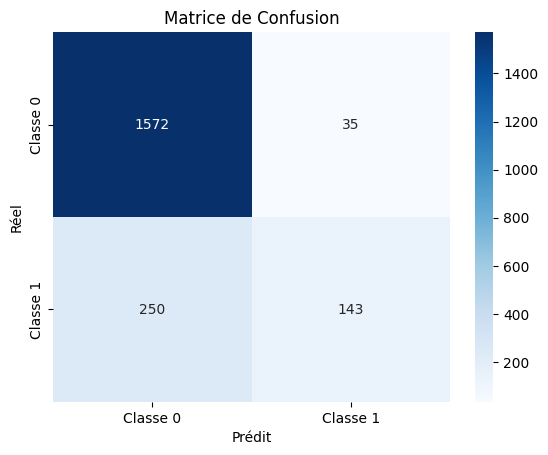

In [232]:
accuracyS = accuracy_score(y_testS, y_predS)
print(f"Accuracy: {accuracyS:.2f}")

# Matrice de confusion
conf_matrix = confusion_matrix(y_testS, y_predS)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1' ], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

In [233]:
print(f"Précision du modèle : {accuracyS:.2f}")
print("\nRapport de classification :\n", classification_report(y_testS, y_predS))

Précision du modèle : 0.86

Rapport de classification :
               precision    recall  f1-score   support

           0       0.86      0.98      0.92      1607
           1       0.80      0.36      0.50       393

    accuracy                           0.86      2000
   macro avg       0.83      0.67      0.71      2000
weighted avg       0.85      0.86      0.84      2000



In [234]:
y_scores_Svm = svm.decision_function(X_testS)
fprsvm, tprsvm, _ = roc_curve(y_testS, y_scores_Svm)

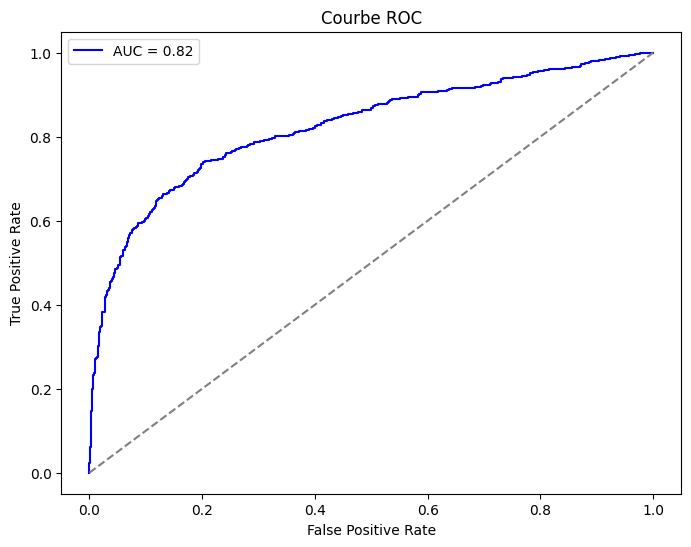

In [235]:
from sklearn.metrics import auc

roc_aucsvm = auc(fprsvm, tprsvm)

# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fprsvm, tprsvm, color='blue', label=f'AUC = {roc_aucsvm:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

### 5. Validation des donnes :

In [236]:
from sklearn.model_selection import cross_val_score, KFold

model = svm
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x, y, cv=kf)
print(f"Scores de validation croisée : {scores}")
print(f"Score moyen : {scores.mean():.2f}")

Scores de validation croisée : [0.8035 0.7915 0.79   0.8015 0.795 ]
Score moyen : 0.80


#### Le code utilise la validation croisée pour évaluer la performance d'un modèle de machine learning. Cependant, il semble y avoir un avertissement concernant la convergence du modèle, ce qui pourrait nécessiter un ajustement des paramètres ou une normalisation des données.

# Conclusion :

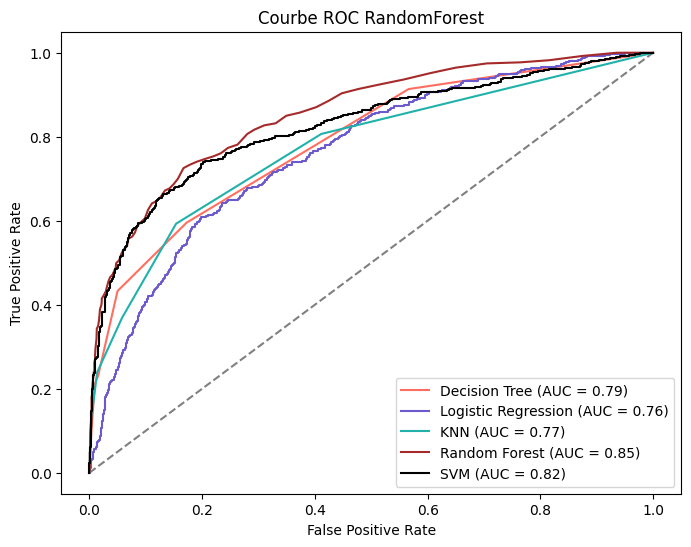

In [237]:
# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.plot(fprdt, tprdt, color='#FF6F61', label=f'Decision Tree (AUC = {roc_aucDT:.2f})')       
plt.plot(fprlog, tprlog, color='#6A5ACD', label=f'Logistic Regression (AUC = {roc_aucLOG:.2f})')    
plt.plot(fprknn, tprknn, color='#20B2AA', label=f'KNN (AUC = {roc_aucKNN:.2f})')                    
plt.plot(fprR, tprR, color='brown', label=f'Random Forest (AUC = {roc_aucR:.2f})')
plt.plot(fprsvm, tprsvm, color='black', label=f'SVM (AUC = {roc_aucsvm:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC RandomForest')
plt.legend()
plt.show()

### Le code compare la performance des différents modèles en traçant leur courbe ROC et en affichant leur AUC pour évaluer leur capacité à classer correctement les données. Plus l'AUC est élevé, mieux le modèle est performant.

# ***Equilibrages du classes de la variable cible***

In [238]:
x = df.drop(columns=['Exited', 'RowNumber' , 'CustomerId' ])
y = df['Exited'] 

In [239]:
x.columns

Index(['CreditScore', 'Geography', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Gender_Female',
       'Gender_Male'],
      dtype='str')

In [240]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto' , random_state=42)
X_res, y_res = smote.fit_resample(x, y)

In [241]:
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(sampling_strategy=0.5, random_state=42)
# X_res, y_res = smote.fit_resample(x, y)

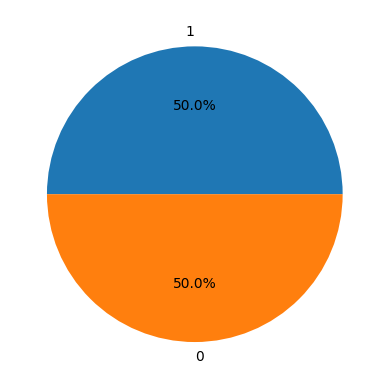

In [242]:
plt.pie(y_res.value_counts(),labels=df['Exited'].unique(),autopct='%1.1f%%')
plt.show()

In [243]:
x.shape

(10000, 11)

In [244]:
X_res.shape

(15926, 11)

In [245]:
y_res.value_counts()

Exited
1    7963
0    7963
Name: count, dtype: int64

<div style="text-align: center;">
    <h2>logisticRegression</h2>
</div>

### 1. separation des donnees / Division en train et test

In [246]:
x_trainl, x_testl, y_trainl, y_testl = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
print(f"Train size: {x_trainl.shape}, Test size: {x_testl.shape}")

Train size: (12740, 11), Test size: (3186, 11)


### 2. Normalisation 

In [247]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_trainl= scaler.fit_transform(x_trainl)
x_testl= scaler.fit_transform(x_testl)

#### Normalisation : Transformation des données pour qu'elles aient une échelle comparable, ce qui est souvent nécessaire pour les modèles de machine learning. 


### 3. Modélisation et entraînement d’un modèle de classification :

In [248]:
model = LogisticRegression(max_iter=1000)
model.fit(x_trainl, y_trainl)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 4. Prédiction sur l'ensemble de test / visualisation :

In [249]:
y_predLOG = model.predict(x_testl)

Accuracy: 0.80


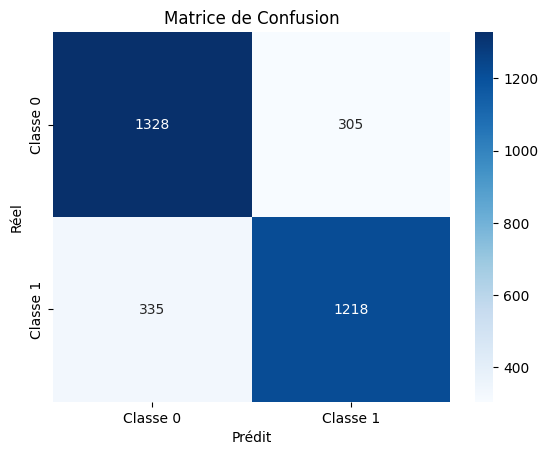

In [250]:
accuracyLOG = accuracy_score(y_testl, y_predLOG )
print(f"Accuracy: {accuracyLOG:.2f}")

# Matrice de confusion
conf_matrix = confusion_matrix(y_testl, y_predLOG )
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

In [251]:
print(f"Précision du modèle : {accuracyLOG:.2f}")
print("\nRapport de classification :\n", classification_report(y_testl, y_predLOG ))

Précision du modèle : 0.80

Rapport de classification :
               precision    recall  f1-score   support

           0       0.80      0.81      0.81      1633
           1       0.80      0.78      0.79      1553

    accuracy                           0.80      3186
   macro avg       0.80      0.80      0.80      3186
weighted avg       0.80      0.80      0.80      3186



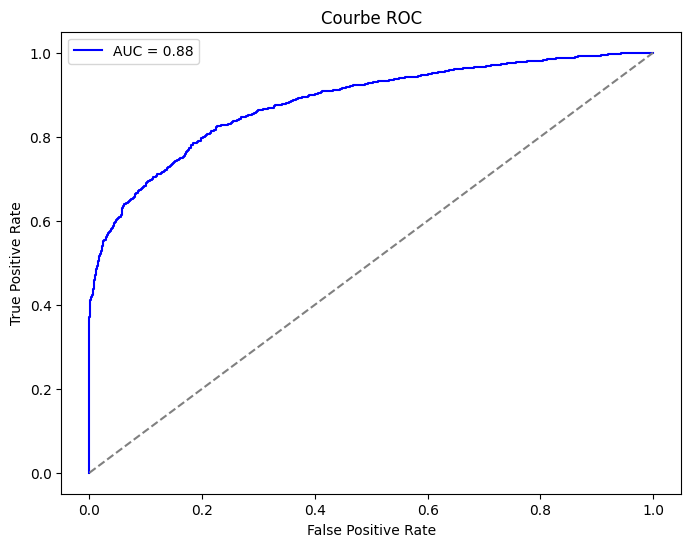

In [252]:
# Calcul de la courbe ROC
y_scoresLOG = model.predict_proba(x_testl)[:, 1]
fprLOG, tprLOG, _ = roc_curve(y_testl, y_scoresLOG)
roc_aucLOG = auc(fprLOG, tprLOG)

plt.figure(figsize=(8, 6))
plt.plot(fprLOG, tprLOG, color='blue', label=f'AUC = {roc_aucLOG:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()


### 5. Validation des donnes :

In [253]:
from sklearn.model_selection import cross_val_score, KFold

model = model
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x, y, cv=kf)
print(f"Scores de validation croisée : {scores}")
print(f"Score moyen : {scores.mean():.2f}")

c:\Users\sohaib bakkali\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\sohaib bakkali\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown

Scores de validation croisée : [0.815  0.8045 0.8015 0.8145 0.8145]
Score moyen : 0.81


c:\Users\sohaib bakkali\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<div style="text-align: center;">
    <h2>K-Nearest Neighbors</h2>
</div>

### 1. separation des donnees / Division en train et test

In [254]:
x_traink, x_testk, y_traink, y_testk = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
print(f"Train size: {x_traink.shape}, Test size: {x_testk.shape}")

Train size: (12740, 11), Test size: (3186, 11)


### 2. Normalisation 

In [255]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_traink= scaler.fit_transform(x_traink)
x_testk= scaler.fit_transform(x_testk)

### 3. Modélisation et entraînement d’un modèle de classification :

In [256]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
# Fit the model
knn.fit(x_traink , y_traink)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [257]:
KNN_y_pred = knn.predict(x_testk)

### 4. Prédiction sur l'ensemble de test / visualisation :

In [258]:
KNN__accuracy = accuracy_score(y_testk, KNN_y_pred)
print(f"Précision du modèle : {KNN__accuracy:.2f}")
print("\nRapport de classification :\n", classification_report(y_testk, KNN_y_pred))

Précision du modèle : 0.85

Rapport de classification :
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1633
           1       0.85      0.85      0.85      1553

    accuracy                           0.85      3186
   macro avg       0.85      0.85      0.85      3186
weighted avg       0.85      0.85      0.85      3186



Accuracy: 0.85


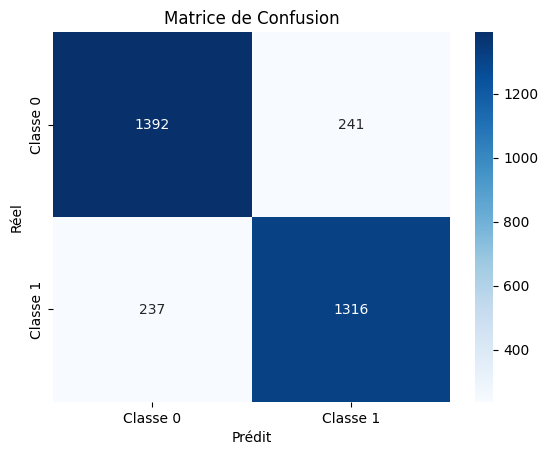

In [259]:
print(f"Accuracy: {KNN__accuracy:.2f}")

# Matrice de confusion
conf_matrix = confusion_matrix(y_testk, KNN_y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1' ], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

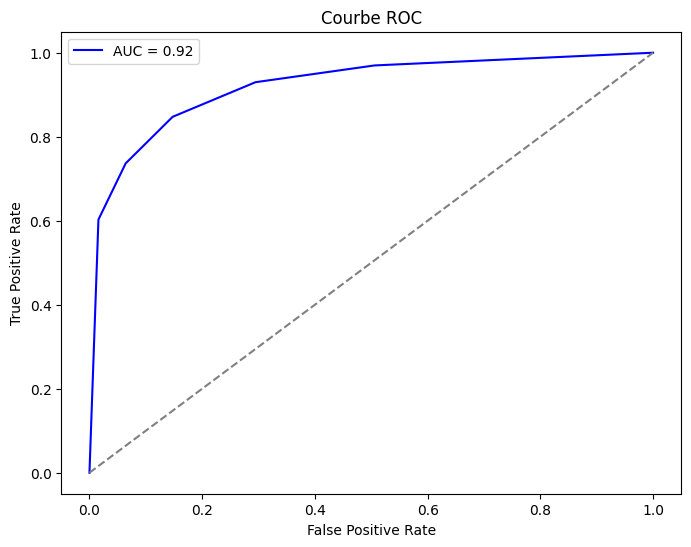

In [260]:
# Calcul de la courbe ROC
KNN_y_scores = knn.predict_proba(x_testk)[:, 1]
fprKNN, tprKNN, _ = roc_curve(y_testk, KNN_y_scores)
roc_aucKNN = auc(fprKNN, tprKNN)

# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fprKNN, tprKNN, color='blue', label=f'AUC = {roc_aucKNN:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

### 5. Validation des donnes :

In [261]:
from sklearn.model_selection import cross_val_score, KFold

model = knn
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x, y, cv=kf)
print(f"Scores de validation croisée : {scores}")
print(f"Score moyen : {scores.mean():.2f}")

Scores de validation croisée : [0.764  0.7575 0.7595 0.7675 0.7675]
Score moyen : 0.76


<div style="text-align: center;">
    <h2>Decision Tree</h2>
</div>

### 1. separation des donnees / Division en train et test

In [262]:
xd_train, xd_test, yd_train, yd_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
print(f"Train size: {xd_train.shape}, Test size: {xd_test.shape}")

Train size: (12740, 11), Test size: (3186, 11)


### 2. Normalisation 

In [263]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xd_train= scaler.fit_transform(xd_train)
xd_test= scaler.fit_transform(xd_test)

### 3. Modélisation et entraînement d’un modèle de classification :

In [264]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion="gini", max_depth=7, random_state=42)
dt.fit(xd_train, yd_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [265]:
ydt_pred = dt.predict(xd_test)

### 4. Prédiction sur l'ensemble de test / visualisation :

In [266]:
# Évaluation du modèle
accuracy_dt = accuracy_score(yd_test, ydt_pred)
print(f"Précision du modèle : {accuracy_dt:.2f}")

Précision du modèle : 0.84


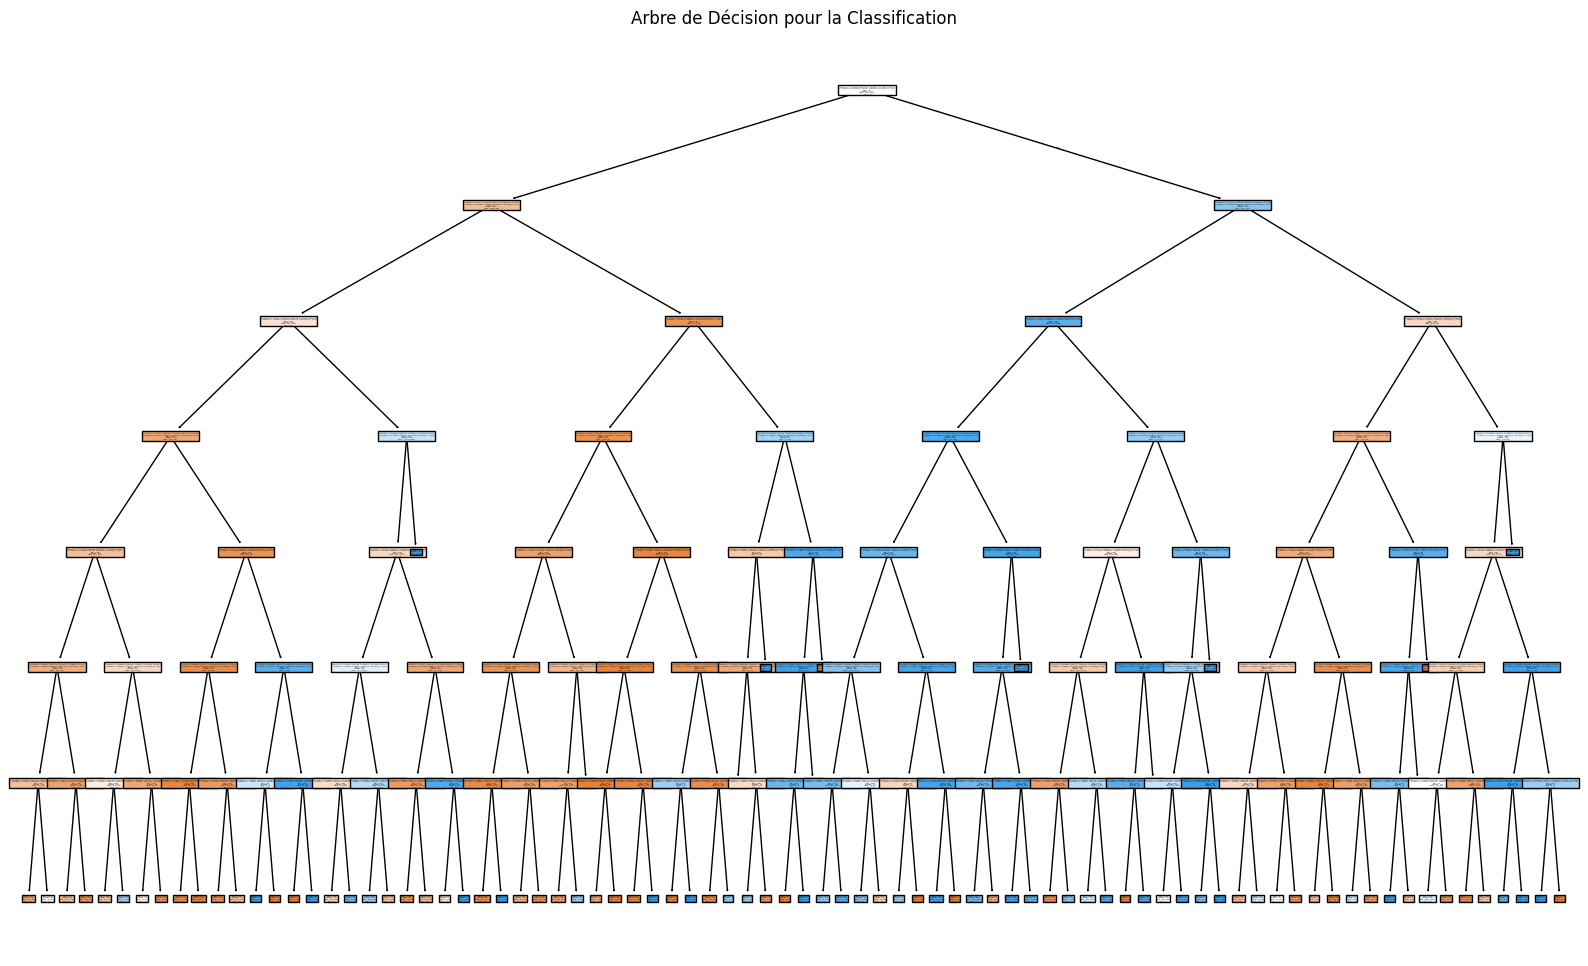

In [267]:
# Visualisation de l’arbre de décision
from sklearn import tree
from sklearn.tree import  plot_tree
plt.figure(figsize=(20, 12))
plot_tree(dt, filled=True, feature_names=xd_train, class_names=True)
plt.title("Arbre de Décision pour la Classification")
plt.show()

<Axes: >

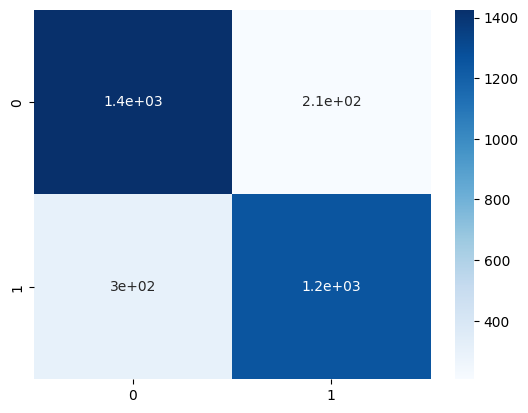

In [268]:
import seaborn as sns

sns.heatmap(confusion_matrix(yd_test, ydt_pred), annot=True, cmap='Blues')

In [269]:
print(f"Précision du modèle : {accuracy_dt:.2f}")
print("\nRapport de classification :\n", classification_report(yd_test, ydt_pred))

Précision du modèle : 0.84

Rapport de classification :
               precision    recall  f1-score   support

           0       0.82      0.87      0.85      1633
           1       0.86      0.80      0.83      1553

    accuracy                           0.84      3186
   macro avg       0.84      0.84      0.84      3186
weighted avg       0.84      0.84      0.84      3186



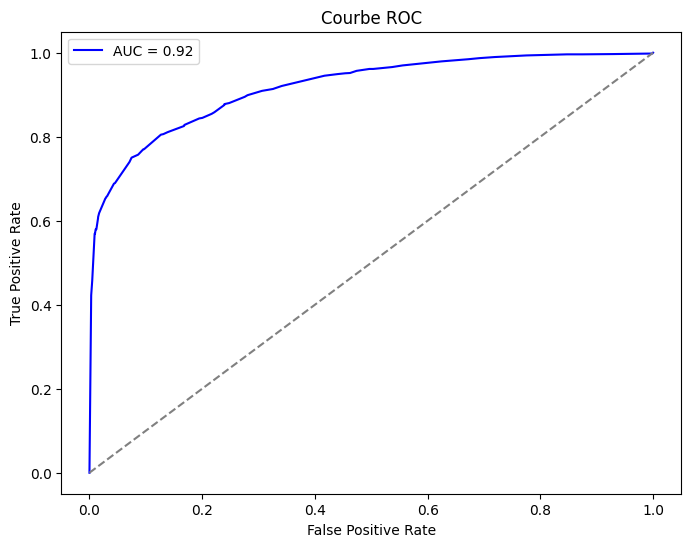

In [270]:
# Calcul de la courbe ROC
ydt_scores = dt.predict_proba(xd_test)[:, 1]
fprDT, tprDT, _ = roc_curve(yd_test, ydt_scores)
roc_aucDT = auc(fprDT, tprDT)

# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fprDT, tprDT, color='blue', label=f'AUC = {roc_aucDT:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

### 5. Validation des donnes :

In [271]:
from sklearn.model_selection import cross_val_score, KFold

model = dt
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_res, y_res, cv=kf)
print(f"Scores de validation croisée : {scores}")
print(f"Score moyen : {scores.mean():.2f}")

Scores de validation croisée : [0.83929692 0.82825746 0.83202512 0.82543171 0.82511774]
Score moyen : 0.83


<div style="text-align: center;">
    <h2>Random Forest</h2>
</div>

### 1. separation des donnees / Division en train et test

In [272]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

### 3. Modélisation et entraînement d’un modèle de classification :

In [273]:
rf=RandomForestClassifier(n_estimators = 80, criterion = "gini", max_depth = 21,max_features='log2',random_state=42)
rf.fit(Xr_train, yr_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",80
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",21
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [274]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=17,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='log2',
    class_weight='balanced',
    random_state=42
    )
rf.fit(Xr_train, yr_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",17
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### 4. Prédiction sur l'ensemble de test / visualisation :

In [275]:
y_pred_rd = rf.predict(Xr_test)

In [276]:
accuracy_rd = accuracy_score(yr_test, y_pred_rd)


In [277]:
print(f"Précision du modèle : {accuracy_rd:.2f}")
print("\nRapport de classification :\n", classification_report(yr_test, y_pred_rd))

Précision du modèle : 0.88

Rapport de classification :
               precision    recall  f1-score   support

           0       0.88      0.89      0.88      1633
           1       0.89      0.87      0.88      1553

    accuracy                           0.88      3186
   macro avg       0.88      0.88      0.88      3186
weighted avg       0.88      0.88      0.88      3186



In [278]:
# Matrice de confusion
conf_matrix = confusion_matrix(yr_test, y_pred_rd)
print("\nMatrice de confusion :\n", conf_matrix)


Matrice de confusion :
 [[1459  174]
 [ 208 1345]]


<Axes: >

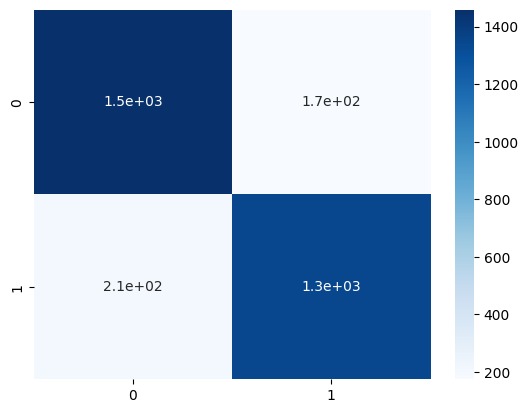

In [279]:
import seaborn as sns

sns.heatmap(confusion_matrix(yr_test, y_pred_rd), annot=True, cmap='Blues')

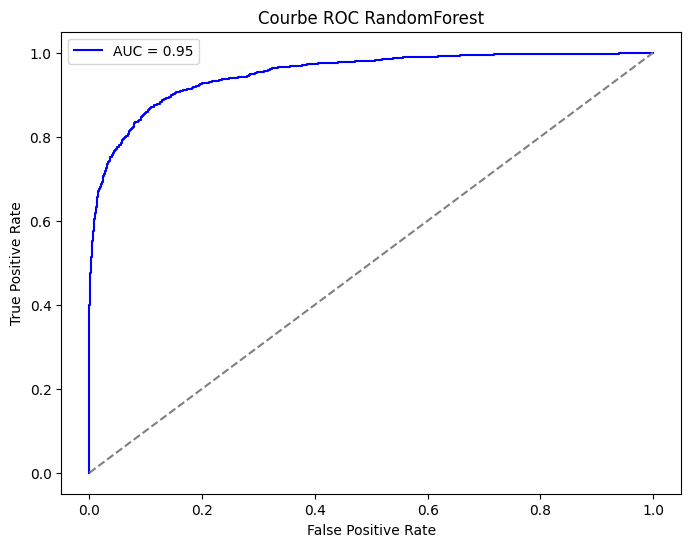

In [280]:
# Calcul de la courbe ROC
y_scoresR = rf.predict_proba(Xr_test)[:, 1]
fprR, tprR, _ = roc_curve(yr_test, y_scoresR)
roc_aucR = auc(fprR, tprR)

plt.figure(figsize=(8, 6))
plt.plot(fprR, tprR, color='blue', label=f'AUC = {roc_aucR:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC RandomForest')
plt.legend()
plt.show()

### 5. Validation des donnes :

In [281]:
from sklearn.model_selection import cross_val_score, KFold

model = rf
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_res, y_res, cv=kf)
print(f"Scores de validation croisée : {scores}")
print(f"Score moyen : {scores.mean():.2f}")

Scores de validation croisée : [0.88135593 0.86907378 0.86405024 0.87189953 0.86467818]
Score moyen : 0.87


<div style="text-align: center;">
    <h2>SVM: Support Vector Machine</h2>
</div>

### 1. separation des donnees / Division en train et test

In [282]:
X_trainS, X_testS, y_trainS, y_testS = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

### 2. Normalisation 

In [283]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_trainS= scaler.fit_transform(X_trainS)
X_testS= scaler.fit_transform(X_testS)

In [284]:
# from sklearn.svm import SVC
# svm_classifier = SVC(kernel="rbf", C=1.0)
# svm_classifier.fit(x_trainS, y_trainS)

### 3. Modélisation et entraînement d’un modèle de classification :

In [285]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_trainS, y_trainS)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### 4. Prédiction sur l'ensemble de test / visualisation :

In [286]:
y_predS = svm.predict(X_testS)

accuracyS = accuracy_score(y_testS, y_predS)
print(f"Accuracy: {accuracyS:.2f}")

Accuracy: 0.86


Accuracy: 0.86


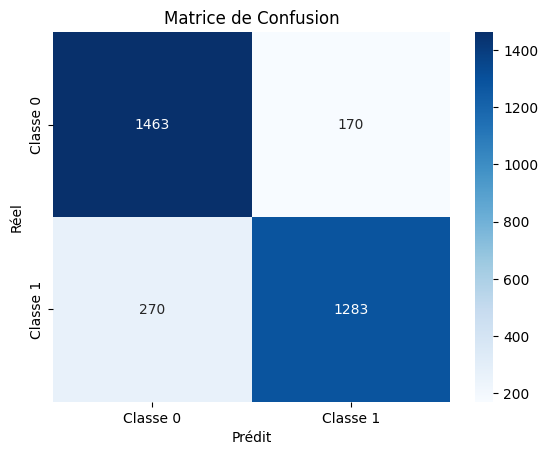

In [287]:
accuracyS = accuracy_score(y_testS, y_predS)
print(f"Accuracy: {accuracyS:.2f}")

# Matrice de confusion
conf_matrix = confusion_matrix(y_testS, y_predS)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1' ], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

In [288]:

print(f"Précision du modèle : {accuracyS:.2f}")
print("\nRapport de classification :\n", classification_report(y_testS, y_predS))

Précision du modèle : 0.86

Rapport de classification :
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1633
           1       0.88      0.83      0.85      1553

    accuracy                           0.86      3186
   macro avg       0.86      0.86      0.86      3186
weighted avg       0.86      0.86      0.86      3186



In [289]:
y_scores_Svm = svm.decision_function(X_testS)
fprsvm, tprsvm, _ = roc_curve(y_testS, y_scores_Svm)

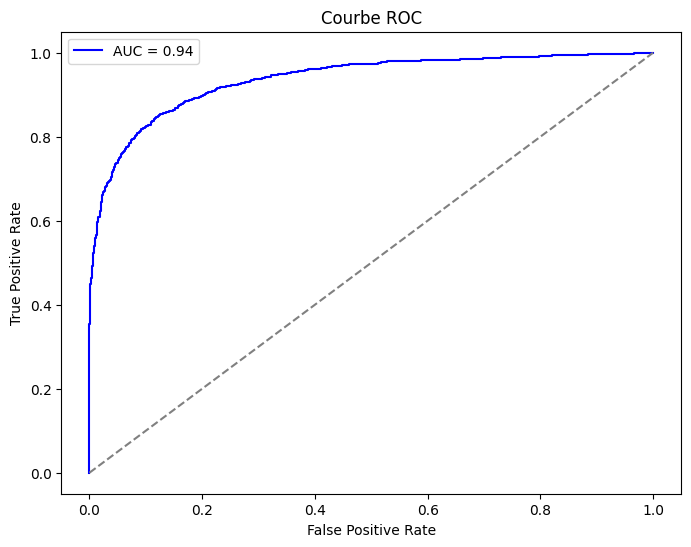

In [290]:
from sklearn.metrics import auc

roc_aucsvm = auc(fprsvm, tprsvm)

# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fprsvm, tprsvm, color='blue', label=f'AUC = {roc_aucsvm:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

### 5. Validation des donnes :

In [291]:
from sklearn.model_selection import cross_val_score, KFold

model = svm
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_res, y_res, cv=kf)
print(f"Scores de validation croisée : {scores}")
print(f"Score moyen : {scores.mean():.2f}")

Scores de validation croisée : [0.56779661 0.57959184 0.5466248  0.57927786 0.58178964]
Score moyen : 0.57


## Conclusion :

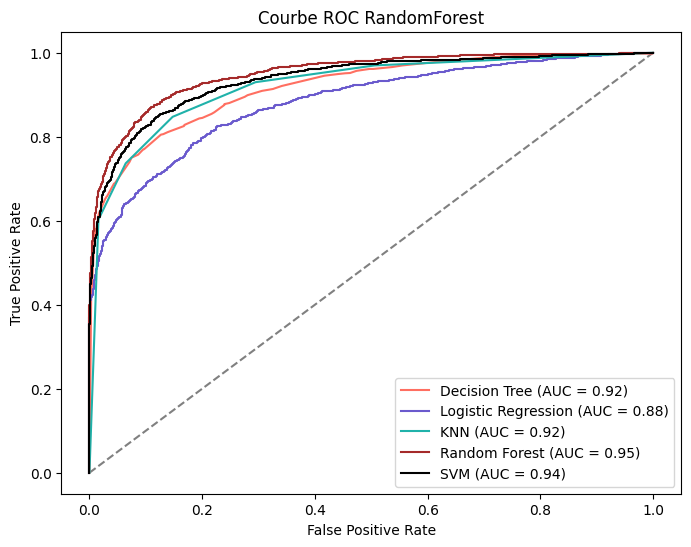

In [292]:
# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.plot(fprDT, tprDT, color='#FF6F61', label=f'Decision Tree (AUC = {roc_aucDT:.2f})')       
plt.plot(fprLOG, tprLOG, color='#6A5ACD', label=f'Logistic Regression (AUC = {roc_aucLOG:.2f})')    
plt.plot(fprKNN, tprKNN, color='#20B2AA', label=f'KNN (AUC = {roc_aucKNN:.2f})')                    
plt.plot(fprR, tprR, color='brown', label=f'Random Forest (AUC = {roc_aucR:.2f})')
plt.plot(fprsvm, tprsvm, color='black', label=f'SVM (AUC = {roc_aucsvm:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC RandomForest')
plt.legend()
plt.show()

<div style="text-align: center;">
    <h2>logisticRegression</h2>
</div>

In [293]:
print(f"Précision du modèle : {accuracyLOG:.2f}")
print("\nRapport de classification :\n", classification_report(y_testl, y_predLOG ))

Précision du modèle : 0.80

Rapport de classification :
               precision    recall  f1-score   support

           0       0.80      0.81      0.81      1633
           1       0.80      0.78      0.79      1553

    accuracy                           0.80      3186
   macro avg       0.80      0.80      0.80      3186
weighted avg       0.80      0.80      0.80      3186



Accuracy: 0.80


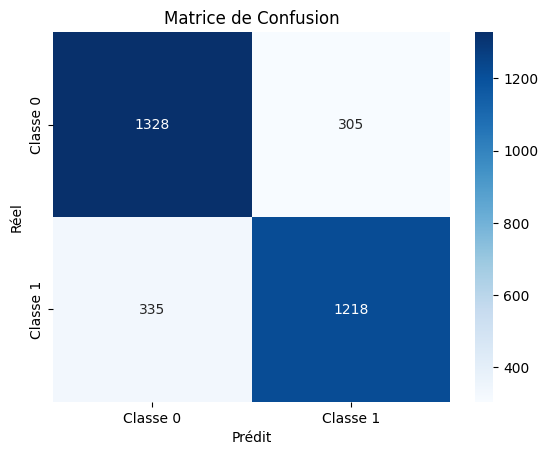

In [294]:
print(f"Accuracy: {accuracyLOG:.2f}")

# Matrice de confusion
conf_matrix = confusion_matrix(y_testl, y_predLOG )
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

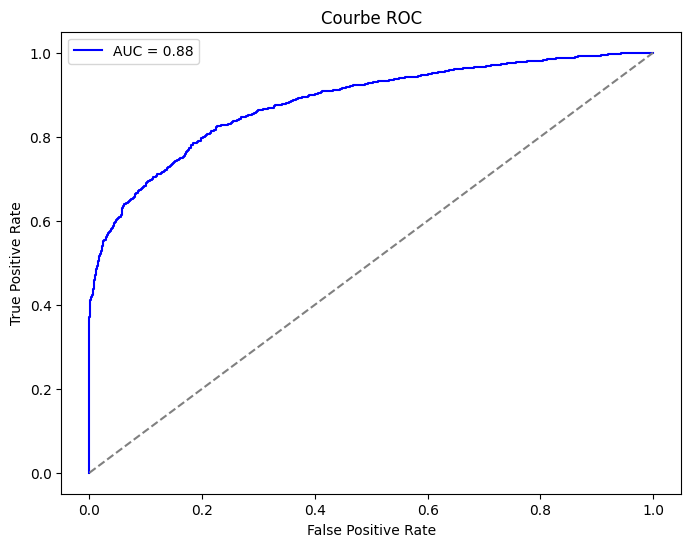

In [295]:
plt.figure(figsize=(8, 6))
plt.plot(fprLOG, tprLOG, color='blue', label=f'AUC = {roc_aucLOG:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()


<div style="text-align: center;">
    <h2>K-Nearest Neighbors</h2>
</div>

In [296]:
print(f"Précision du modèle : {KNN__accuracy:.2f}")
print("\nRapport de classification :\n", classification_report(y_testk, KNN_y_pred))

Précision du modèle : 0.85

Rapport de classification :
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1633
           1       0.85      0.85      0.85      1553

    accuracy                           0.85      3186
   macro avg       0.85      0.85      0.85      3186
weighted avg       0.85      0.85      0.85      3186



Accuracy: 0.85


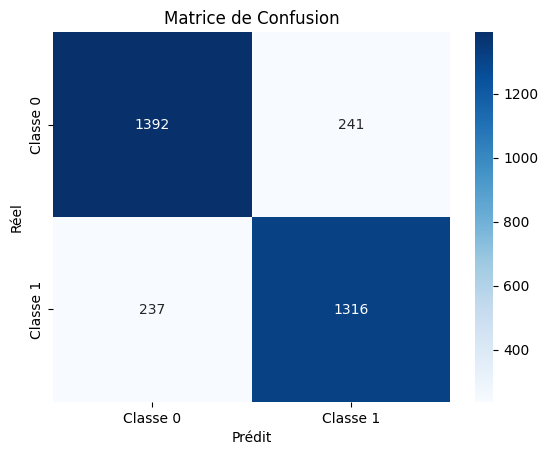

In [297]:
print(f"Accuracy: {KNN__accuracy:.2f}")

# Matrice de confusion
conf_matrix = confusion_matrix(y_testk, KNN_y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1' ], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

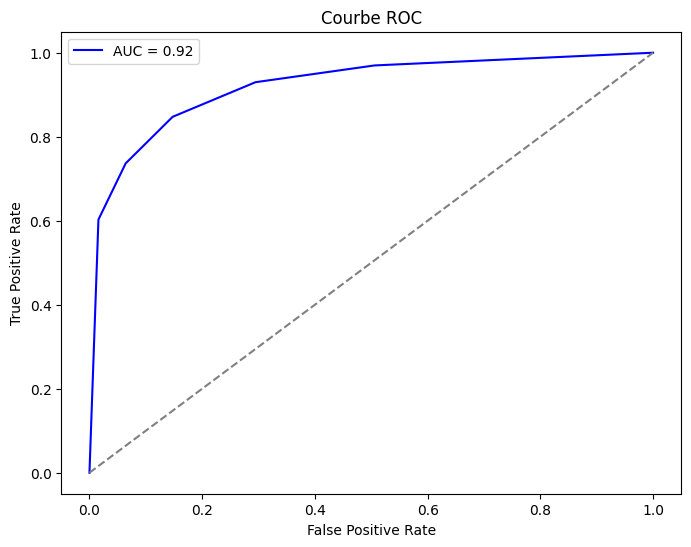

In [298]:
# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fprKNN, tprKNN, color='blue', label=f'AUC = {roc_aucKNN:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

<div style="text-align: center;">
    <h2>Decision Tree</h2>
</div>

In [299]:
print(f"Précision du modèle : {accuracy_dt:.2f}")
print("\nRapport de classification :\n", classification_report(yd_test, ydt_pred))

Précision du modèle : 0.84

Rapport de classification :
               precision    recall  f1-score   support

           0       0.82      0.87      0.85      1633
           1       0.86      0.80      0.83      1553

    accuracy                           0.84      3186
   macro avg       0.84      0.84      0.84      3186
weighted avg       0.84      0.84      0.84      3186



<Axes: >

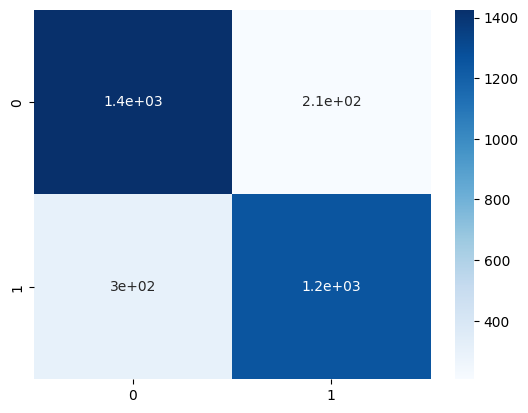

In [300]:
import seaborn as sns

sns.heatmap(confusion_matrix(yd_test, ydt_pred), annot=True, cmap='Blues')

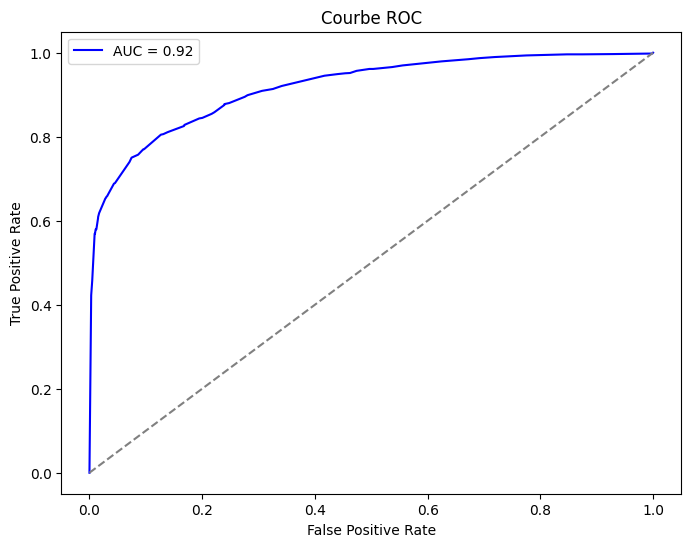

In [301]:
# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fprDT, tprDT, color='blue', label=f'AUC = {roc_aucDT:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

<div style="text-align: center;">
    <h2>Random Forest</h2>
</div>

In [302]:
print(f"Précision du modèle : {accuracy_rd:.2f}")
print("\nRapport de classification :\n", classification_report(yr_test, y_pred_rd))

Précision du modèle : 0.88

Rapport de classification :
               precision    recall  f1-score   support

           0       0.88      0.89      0.88      1633
           1       0.89      0.87      0.88      1553

    accuracy                           0.88      3186
   macro avg       0.88      0.88      0.88      3186
weighted avg       0.88      0.88      0.88      3186



In [303]:
# Matrice de confusion
conf_matrix = confusion_matrix(yr_test, y_pred_rd)
print("\nMatrice de confusion :\n", conf_matrix)


Matrice de confusion :
 [[1459  174]
 [ 208 1345]]


<Axes: >

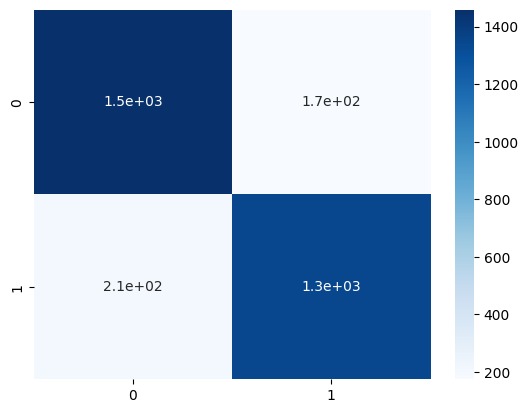

In [304]:
import seaborn as sns

sns.heatmap(confusion_matrix(yr_test, y_pred_rd), annot=True, cmap='Blues')

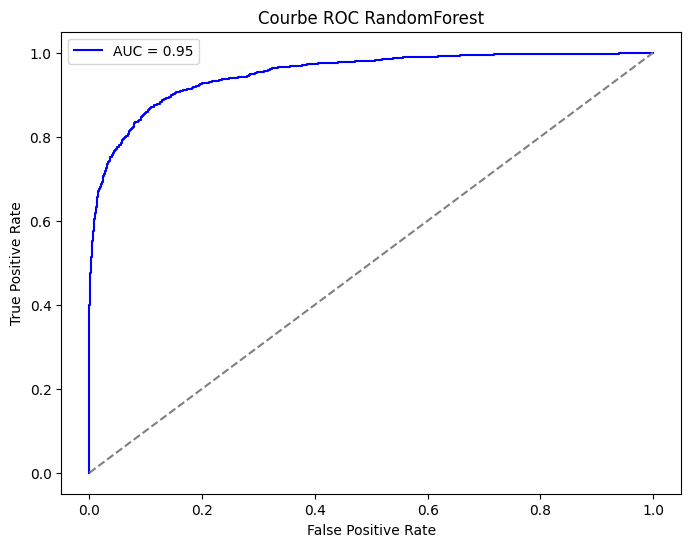

In [305]:
plt.figure(figsize=(8, 6))
plt.plot(fprR, tprR, color='blue', label=f'AUC = {roc_aucR:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC RandomForest')
plt.legend()
plt.show()

<div style="text-align: center;">
    <h2>SVM: Support Vector Machine</h2>
</div>

In [306]:

print(f"Précision du modèle : {accuracyS:.2f}")
print("\nRapport de classification :\n", classification_report(y_testS, y_predS))

Précision du modèle : 0.86

Rapport de classification :
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1633
           1       0.88      0.83      0.85      1553

    accuracy                           0.86      3186
   macro avg       0.86      0.86      0.86      3186
weighted avg       0.86      0.86      0.86      3186



Accuracy: 0.86


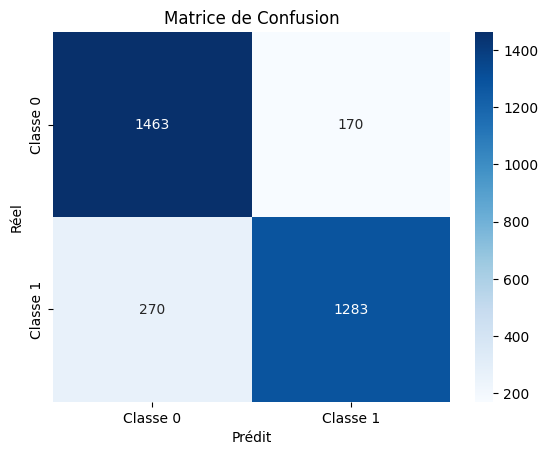

In [307]:
print(f"Accuracy: {accuracyS:.2f}")
# Matrice de confusion
conf_matrix = confusion_matrix(y_testS, y_predS)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Classe 0', 'Classe 1' ], yticklabels=['Classe 0', 'Classe 1'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

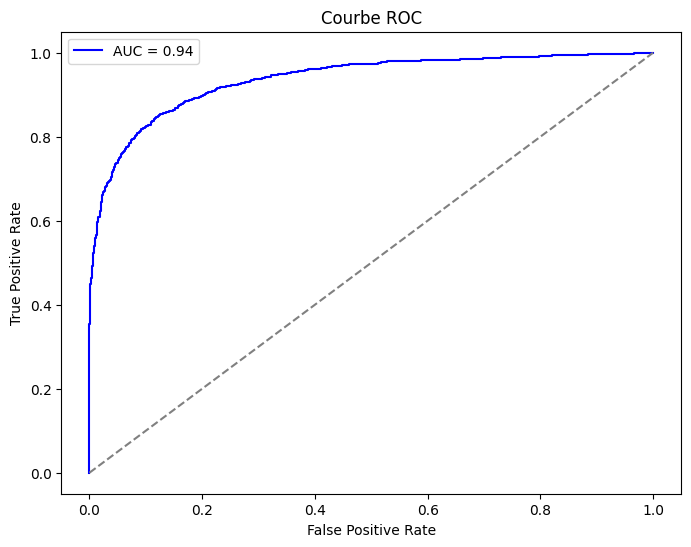

In [308]:
# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fprsvm, tprsvm, color='blue', label=f'AUC = {roc_aucsvm:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

# ***Prediction du modele le plus perforemant***:

# RQ : 
#### Ce projet montre qu’un modèle de Machine Learning permet de détecter les clients susceptibles de quitter une banque.
#### Et le meilleur modele utiliser est **RandomForest** , donc on le reuvaluer avec des nouveuax donees, pour rvaluer la performance de ce modele  :

In [309]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


model_results = {
    "Logistic Regression": (y_testl, y_predLOG),
    "KNN": (y_testk, KNN_y_pred),
    "Decision Tree": (yd_test, ydt_pred),
    "Random Forest": (yr_test, y_pred_rd),
    "SVM": (y_testS, y_predS)
}

comparaison_models = []

for model_name, (y_true, y_pred) in model_results.items():
    comparaison_models.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    })

comparaison_models = pd.DataFrame(comparaison_models)

comparaison_models[["Accuracy", "Precision", "Recall", "F1-score"]] = comparaison_models[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].round(4)

comparaison_models = comparaison_models.sort_values(
    by=["F1-score", "Accuracy"], ascending=False
).reset_index(drop=True)

comparaison_models

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.8801,0.8855,0.8661,0.8757
1,SVM,0.8619,0.8830,0.8261,0.8536
2,KNN,0.8500,0.8452,0.8474,0.8463
3,Decision Tree,0.8399,0.8579,0.8049,0.8306
4,Logistic Regression,0.7991,0.7997,0.7843,0.7919


In [310]:
rf.predict([[619,	0,	42,	2,	0.00,	1,	1,	1	,101348.88	,	True ,	False]])

c:\Users\sohaib bakkali\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

In [311]:
rf.predict([[608,	2,	41,	1	,83807.86,	1	,0	,1,112542.58	,	True	,False]])

c:\Users\sohaib bakkali\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

In [312]:
df

,RowNumber,CustomerId,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Female,Gender_Male
0,1,15634602,619,0,42,2,0.00,1,1,1,101348.88,1,True,False
1,2,15647311,608,2,41,1,83807.86,1,0,1,112542.58,0,True,False
2,3,15619304,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False
3,4,15701354,699,0,39,1,0.00,2,0,0,93826.63,0,True,False
4,5,15737888,850,2,43,2,125510.82,1,1,1,79084.10,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,771,0,39,5,0.00,2,1,0,96270.64,0,False,True
9996,9997,15569892,516,0,35,10,57369.61,1,1,1,101699.77,0,False,True
9997,9998,15584532,709,0,36,7,0.00,1,0,1,42085.58,1,True,False
9998,9999,15682355,772,1,42,3,75075.31,2,1,0,92888.52,1,False,True


## Enregistrement du modele

In [331]:
import joblib
feature_columns = Xr_train.columns.tolist()

joblib.dump(rf, 'best_model_classifier.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

['feature_columns.pkl']

## Chargement du modèle sauvegardé

Cette cellule recharge le modèle, le scaler et les colonnes sauvegardées.

In [332]:
import joblib
loaded_model = joblib.load('best_model_classifier.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_feature_columns = joblib.load('feature_columns.pkl')

In [313]:
# Sauvegarde
#import
#with open('random_forest_model.pkl', 'wb') as f:
#

# Deploying the Model to a Web App

Cette section génère une application Streamlit simple et professionnelle.  
L’application charge le modèle sauvegardé, le scaler et les colonnes utilisées pendant l’entraînement, puis permet à l’utilisateur de saisir les informations d’un client.

Les variables complexes sont expliquées directement dans l’interface.  
Les variables binaires sont affichées avec des labels clairs comme Oui / Non, et le genre est affiché avec Homme / Femme.

In [334]:
app_code = """
import streamlit as st
import pandas as pd
import joblib

# =========================
# Configuration de la page
# =========================
st.set_page_config(
    page_title="Bank Customer Churn Prediction",
    page_icon="🏦",
    layout="wide"
)

# =========================
# Style CSS
# =========================
st.markdown(
    \"\"\"
    <style>
    .main-title {
        font-size: 36px;
        font-weight: bold;
        color: #1f4e79;
        text-align: center;
        margin-bottom: 10px;
    }
    .subtitle {
        text-align: center;
        font-size: 18px;
        color: #555;
        margin-bottom: 30px;
    }
    .result-box {
        padding: 25px;
        border-radius: 15px;
        background-color: #f5f7fa;
        border: 1px solid #ddd;
        margin-top: 20px;
    }
    .risk-high {
        color: #c0392b;
        font-size: 24px;
        font-weight: bold;
    }
    .risk-low {
        color: #27ae60;
        font-size: 24px;
        font-weight: bold;
    }
    </style>
    \"\"\",
    unsafe_allow_html=True
)

# =========================
# Chargement des fichiers
# =========================
@st.cache_resource
def load_files():
    model = joblib.load("best_model_classifier.pkl")
    scaler = joblib.load("scaler.pkl")
    feature_columns = joblib.load("feature_columns.pkl")
    return model, scaler, feature_columns

try:
    model, scaler, feature_columns = load_files()
except FileNotFoundError:
    st.error("Erreur : Un fichier du modèle est introuvable. Vérifiez best_model_classifier.pkl, scaler.pkl et feature_columns.pkl.")
    st.stop()

# =========================
# Titre
# =========================
st.markdown("<div class='main-title'>🏦 Bank Customer Churn Prediction App</div>", unsafe_allow_html=True)
st.markdown(
    "<div class='subtitle'>Cette application prédit si un client risque de quitter la banque à partir de ses informations.</div>",
    unsafe_allow_html=True
)

# =========================
# Sidebar
# =========================
st.sidebar.header("📌 Informations du client")
client_name = st.sidebar.text_input("Nom du client", "sohaib bakkali")

# =========================
# Inputs
# =========================
col1, col2, col3 = st.columns(3)

with col1:
    credit_score = st.number_input(
        "Score de crédit",
        min_value=300,
        max_value=900,
        value=650
    )

    geography = st.selectbox(
        "Pays",
        ["France", "Germany", "Spain"]
    )

    gender_label = st.selectbox(
        "Genre",
        ["Homme", "Femme"]
    )

with col2:
    age = st.number_input(
        "Âge",
        min_value=18,
        max_value=100,
        value=40
    )

    tenure = st.number_input(
        "Ancienneté",
        min_value=0,
        max_value=10,
        value=3
    )

    balance = st.number_input(
        "Solde bancaire",
        min_value=0.0,
        max_value=300000.0,
        value=60000.0
    )

with col3:
    num_of_products = st.selectbox(
        "Nombre de produits bancaires",
        [1, 2, 3, 4]
    )

    has_cr_card_label = st.selectbox(
        "Possède une carte de crédit",
        ["Oui", "Non"]
    )

    is_active_member_label = st.selectbox(
        "Client actif",
        ["Oui", "Non"]
    )

estimated_salary = st.number_input(
    "Salaire estimé",
    min_value=0.0,
    max_value=250000.0,
    value=50000.0
)

# =========================
# Transformation des inputs
# =========================
gender = "Male" if gender_label == "Homme" else "Female"
has_cr_card = 1 if has_cr_card_label == "Oui" else 0
is_active_member = 1 if is_active_member_label == "Oui" else 0

input_data = pd.DataFrame([{
    "CreditScore": credit_score,
    "Geography": geography,
    "Gender": gender,
    "Age": age,
    "Tenure": tenure,
    "Balance": balance,
    "NumOfProducts": num_of_products,
    "HasCrCard": has_cr_card,
    "IsActiveMember": is_active_member,
    "EstimatedSalary": estimated_salary
}])

# =========================
# Bouton de prédiction
# =========================
st.markdown("---")

if st.button("🔍 Prédire le risque de churn", use_container_width=True):

    data_encoded = pd.get_dummies(input_data, drop_first=True)
    data_encoded = data_encoded.reindex(columns=feature_columns, fill_value=0)

    data_scaled = scaler.transform(data_encoded)

    prediction = model.predict(data_scaled)[0]

    if hasattr(model, "predict_proba"):
        probability = model.predict_proba(data_scaled)[0][1]
    else:
        probability = None

    st.subheader("📊 Résultat de la prédiction")

    col_res1, col_res2 = st.columns(2)

    with col_res1:
        st.markdown("<div class='result-box'>", unsafe_allow_html=True)
        st.write(f"**Nom du client :** {client_name}")
        st.write(f"**Pays :** {geography}")
        st.write(f"**Genre :** {gender_label}")
        st.write(f"**Âge :** {age}")
        st.write(f"**Score de crédit :** {credit_score}")
        st.markdown("</div>", unsafe_allow_html=True)

    with col_res2:
        st.markdown("<div class='result-box'>", unsafe_allow_html=True)

        if prediction == 1:
            st.markdown("<p class='risk-high'>⚠️ Client susceptible de quitter la banque</p>", unsafe_allow_html=True)
            st.warning("Ce client présente un risque élevé de churn.")
        else:
            st.markdown("<p class='risk-low'>✅ Client susceptible de rester</p>", unsafe_allow_html=True)
            st.success("Ce client présente un faible risque de churn.")

        st.write(f"**Classe prédite :** {prediction}")

        if probability is not None:
            st.write(f"**Probabilité de churn :** {probability:.2%}")
            st.progress(float(probability))

        st.markdown("</div>", unsafe_allow_html=True)

    st.markdown("---")
    st.subheader("🧾 Données utilisées pour la prédiction")
    st.dataframe(input_data, use_container_width=True)

# =========================
# Footer
# =========================
st.markdown("---")
st.caption("Projet Machine Learning - Bank Customer Churn Prediction")
"""

with open("applicationnn.py", "w", encoding="utf-8") as file:
    file.write(app_code)

print("app.py created successfully!")

app.py created successfully!
